## Project: SVM
### Predict Online Shoppers' Intention To Make a Purchase (By: Archit Pandya)

**`Problem Statement:`** The objective of this project is to predict online shoppers' intention to make a purchase based on various features related to their browsing behaviour. The dataset comprises 12,330 sessions, each belonging to a different user, over a 1-year period. The features include both numerical and categorical attributes, providing insights into users' interactions with the website.

The dataset consists of feature vectors belonging to 12,330 sessions. The dataset was formed so that each session would belong to a different user in a 1-year period to avoid any tendency to a specific campaign, special day, user profile, or period.

**`You are suppose to do EDA,various feature transformations and apply the SVM model with hyperparameter tuning. Since it is imabalanced data, evaluation metric will be f1 score. The benchmark f1 score is 0.55`**

**Feature Description**
<br>`Administrative:` The number of pages of this type (administrative) visited by the user in that session.
<br>`Administrative Duration:` The total amount of time (in seconds) spent by the user on administrative pages during the session.
<br>`Informational:` The number of informational pages visited by the user in that session.
<br>`Informational Duration:` The total time spent by the user on informational pages.
<br>`Product Related:` The number of product-related pages visited by the user.
<br>`Product Related Duration:`  The total time spent by the user on product-related pages.
<br>`Bounce Rates:` The average bounce rate of the pages visited by the user. The bounce rate is the percentage of visitors who navigate away from the site after viewing only one page.
<br>`Exit Rates:` The average exit rate of the pages visited by the user. The exit rate is a metric that shows the percentage of exits from a page.
<br>`PageValues:` The average value of the pages visited by the user. This metric is often used as an indicator of how valuable a page is in terms of generating revenue.
<br>`SpecialDay:` This indicates the closeness of the site visiting time to a specific special day (e.g., Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with a transaction.
<br>`Month:` The month of the year in which the session occurred. 
<br>`OperatingSystems:` The operating system used by the user.
<br>`Browser:` The browser used by the user.
<br>`Region:` The region from which the user is accessing the website.
<br>`Traffic Type:` The type of traffic (e.g., direct, paid search, organic search, referral).
<br>`Visitor Type:` A categorization of users (e.g., Returning Visitor, New Visitor).
<br>`Weekend:` A Boolean indicating whether the session occurred on a weekend.

**Target**
<br>`Revenue:` A binary variable indicating whether the session ended in a transaction (purchase).

## Model Implementation

   - 1.[Imports and Read Data](#1)
       - Import Python libraries and load the data file to conduct data analysis
   - 2.[Data Understanding](#2)
       - Dataframe Shape
       - head and tail
       - Null or Missing Data
       - dtypes and information
   - 3.[Data Preparation](#3)
       - Convert columns into appropriate datatypes
       - Renaming Columns if any
       - Feature Creation
       - Check Duplicates
   - 4.[Feature Understanding (Univariable Analysis)](#4)
       - 4.a. Univariate Analysis (Categorical Features)
       - 4.b. Univariate Analysis (Numerical Features)
       - 4.c. Any potential Outliers
   - 5.[Feature Realtionships (Bivariate Analysis)](#5)
       - 5.a. Bivariate Analysis : Numerical - Numerical
       - 5.b. Bivariate Analysis : Categorical - Categorical
            - List of Hypothesis (2-Tailed Test)
       - 5.c. Bivariate Analysis : Continuous - Categorical
            - List of Hypothesis (2-Tailed Test)
   - 6.[Feature Realtionships (Multivariate Analysis)](#6)
       - 6.a. Pivot Table
   - 7.[Feature Engineering](#7)
       - 7.1 Handle Missing Values
       - 7.2 Feature Generation - Binning
       - 7.3 Identify and Remove Outlier
       - 7.4 Encoding (Label Encoding, One-Hot Encoding, Target Encoding)
   - 8.[Preprocess Data](#8)
       - 8.1 Prepare List for Categorical and Numerical Datatypes
       - 8.2 Decide Encoding Technique for Categorical Datatypes
       - 8.3 Perform 'Frequency Encoding' for Categorical Datatypes
       - 8.4 Decide Encoding Technique for Numerical Datatypes
       - 8.5 Decide Encoding Technique for Numerical Datatypes
       - 8.6 Perform 'Min Max Scaling' and Drop Columns
   - 9.[Build Mode](#9)
       - 9.1 Import Libraries
       - 9.2 Handle the Imbalance
       - 9.3 Instantiate the Classifier and Define Parameter Grid
       - 9.4 Perform GridSearchCV and Get 'Best_Estimator' and 'Best _Params'
       - 9.5 Compute Model Metrices
       - 9.6 List and Visualize the Model Performance

## 1. Imports and Read and Data<a id='1'></a>

In [1]:
# Import necessary Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

print('Imported Libraries')

Imported Libraries


In [2]:
# Read 'credit_data' CSV file that is available from the 'data' directory from which this notebook is saved

online_shoppers_data_df = pd.read_csv('PAhiz_online shoppers intention.csv')
online_shoppers_data_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,10,416.583333,0.0,0.036667,0.000000,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
1,0,0.000000,0,0.0,3,133.500000,0.0,0.088889,0.000000,0.0,Mar,1,2,1,8,Returning_Visitor,False,False
2,5,408.408333,2,47.5,54,1547.477273,0.0,0.017333,0.000000,0.0,Nov,2,2,3,2,Returning_Visitor,True,True
3,0,0.000000,0,0.0,19,686.583333,0.0,0.010526,0.000000,0.0,Dec,1,1,5,2,Returning_Visitor,True,False
4,0,0.000000,0,0.0,69,2734.818254,0.0,0.004353,49.392716,0.0,May,4,5,3,2,Returning_Visitor,False,True


## 2. Data Understanding<a id='2'></a>

In [3]:
# Find row and column counts of 'credit_data' dataframe

online_shoppers_data_df.shape

(12330, 18)

In [4]:
# Find any null values from 'online_shoppers_data'

online_shoppers_data_df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
# Feature Names, Datatypes, Total Rows, Missing for each feature

online_shoppers_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

**Findings** from above outputs

- No Missing Records in the loaded dataframe
- Check for duplicates
- Check each datatype and modify if needed
- Check datatype and make necessary changes as per below:
 <br>`Administrative(int64):` Can be best represented as 'int64'
 <br>`Administrative_Duration(float64):` Can be best represented as 'float64'
 <br>`Informational(int64):` Can be best represented as 'int64'
 <br>`Informational_Duration(float64):` Can be best represented as 'float64'
 <br>`ProductRelated(int64):` Can be best represented as 'int64'
 <br>`ProductRelated_Duration(float64)`: Can be best represented as 'float64' 
 <br>`BounceRates(float64)` Can be best represented as 'float64' 
 <br>`ExitRates(float64):` Can be best represented as 'float64' 
 <br>`PageValues(float64):` Can be best represented as 'float64' 
 <br>`SpecialDay(float64):` Can be best represented as 'float64' 
 <br>`Month(object):` Can be best represented as 'Category'
 <br>`OperatingSystems(int64):` Can be best represented as 'int64'
 <br>`Browser(int64):` Can be best represented as 'int64'
 <br>`Region(int64):` Can be best represented as 'int64'
 <br>`TrafficType(int64):` Can be best represented as 'int64'
 <br>`VisitorType(object):` Can be best represented as 'Category'
 <br>`Weekend(bool):` Can be best represented as 'Category'
 <br>`Revenue(bool):` Can be best represented as 'Category'

## 3. Data Preparation<a id='3'></a>

In [6]:
online_shoppers_data_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,10,416.583333,0.0,0.036667,0.000000,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
1,0,0.000000,0,0.0,3,133.500000,0.0,0.088889,0.000000,0.0,Mar,1,2,1,8,Returning_Visitor,False,False
2,5,408.408333,2,47.5,54,1547.477273,0.0,0.017333,0.000000,0.0,Nov,2,2,3,2,Returning_Visitor,True,True
3,0,0.000000,0,0.0,19,686.583333,0.0,0.010526,0.000000,0.0,Dec,1,1,5,2,Returning_Visitor,True,False
4,0,0.000000,0,0.0,69,2734.818254,0.0,0.004353,49.392716,0.0,May,4,5,3,2,Returning_Visitor,False,True


In [7]:
# Convert to Category Datatype

online_shoppers_data_df['Administrative']   = online_shoppers_data_df['Administrative'].astype('category')
online_shoppers_data_df['Informational']    = online_shoppers_data_df['Informational'].astype('category')
online_shoppers_data_df['SpecialDay']       = online_shoppers_data_df['SpecialDay'].astype('category')
online_shoppers_data_df['Month']            = online_shoppers_data_df['Month'].astype('category')
online_shoppers_data_df['OperatingSystems'] = online_shoppers_data_df['OperatingSystems'].astype('category')
online_shoppers_data_df['Browser']          = online_shoppers_data_df['Browser'].astype('category')
online_shoppers_data_df['Region']           = online_shoppers_data_df['Region'].astype('category')
online_shoppers_data_df['TrafficType']      = online_shoppers_data_df['TrafficType'].astype('category')
online_shoppers_data_df['VisitorType']      = online_shoppers_data_df['VisitorType'].astype('category')
online_shoppers_data_df['Weekend']          = online_shoppers_data_df['Weekend'].astype('category')
online_shoppers_data_df['Revenue']          = online_shoppers_data_df['Revenue'].astype('category')


print(online_shoppers_data_df.dtypes)

Administrative             category
Administrative_Duration     float64
Informational              category
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates                 float64
ExitRates                   float64
PageValues                  float64
SpecialDay                 category
Month                      category
OperatingSystems           category
Browser                    category
Region                     category
TrafficType                category
VisitorType                category
Weekend                    category
Revenue                    category
dtype: object


## 4.Feature Understanding (Univariable Analysis)<a id='4'></a>

### 4a. Univariate analysis: Categorical Features<a id='4-a'></a>

In [8]:
online_shoppers_data_df.select_dtypes(include = ['category', 'object']).dtypes

Administrative      category
Informational       category
SpecialDay          category
Month               category
OperatingSystems    category
Browser             category
Region              category
TrafficType         category
VisitorType         category
Weekend             category
Revenue             category
dtype: object

In [9]:
# Category Group

visitor_grp    = ['Month', 'SpecialDay', 'Weekend', 'Revenue']
os_browser_grp = ['OperatingSystems','Browser','TrafficType','VisitorType']
admn_grp       = ['Administrative','Informational','Region']

In [10]:
# Function to perform Univariate Analysis for Categorical Features

def fn_UVA_category(data, var_group, row, col, default = -1):

    '''
    Univariate_Analysis_categorical
    takes a group of variables (category) and plot/print the value_counts and barplot for max_categories.
    ''' 
    max_categories = 12
    fig, axs = plt.subplots(row, col, figsize=(11, 6))
    if default == 1:
        fig.suptitle("'Month / Special Day' and 'Weekend / Revenue' Counts (Revenue Visitors)", fontsize = 16, fontweight = 'bold')
    elif default == 2:
        fig.suptitle("'OS / Browser' and 'Traffic / Visitor Type' Counts (Revenue Visitors)", fontsize = 16, fontweight = 'bold')
    elif default == 3:
        fig.suptitle("'Administrative / Informational' and 'Regional' Counts (Revenue Visitors)", fontsize = 16, fontweight = 'bold')
    
    for i, ax in enumerate(axs.flatten()):
        col = var_group[i]
        norm_count = data[col].value_counts(normalize = True)[:max_categories]
        n_uni = data[col].nunique()
        
        colors = sns.color_palette('pastel')
        sns.barplot(x=norm_count, y=norm_count.index , order = norm_count.index, ax = ax)
        ax.grid(True)
        ax.set_xlabel('Fraction/Percent', fontsize = 8, fontweight = 'bold')
        ax.set_ylabel(col, fontdict={'weight': 'bold','fontsize':10})
        ax.set_title('Unique Categories = {} \n;'.format(n_uni), fontsize = 8, fontweight = 'bold')

        plt.tight_layout()

    plt.show()

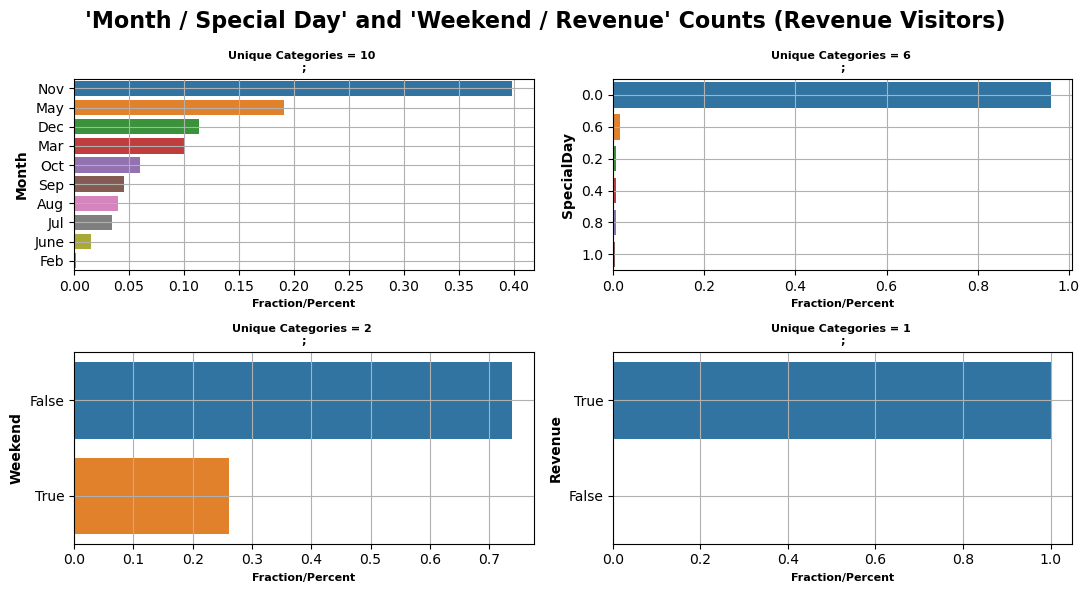

In [11]:
# Find Data Analysis for Online Shoppers who generated 'Revenue'

fn_UVA_category(online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], visitor_grp, 2, 2, 1)

#### Observation (Revenue Generating Visitors)
- **Month**
    - Almost 40% contributed during 'November' for Revenue visitos
    - The rest contributed significantly during 'May','Dec','Mar','Oct' respectively 
- **VisitorType**
    - Almost 75% contributed by 'Returninig_Type'
    - Almost 25% contributed by 'New_Visitor' and 'Other'
- **Weeked**
    - Almost 75% contributed during 'Non-Weekend'
    - Almost 25% contributed during 'Weekend'

**Things to investigate**

    - How to support and maximize contribution during 'November'
    - How to maximize revenue activities during low revenue months like 'Jan','Feb','Jun','Jul','Aug' etc.
    - How to sustain 'Returning_Visitor' and continue making Revenue generation visits
    - How to maximize 'New_Visitor' and 'Other' making more Revenue generating visits
    - How to maximize 'Weekend' more attractive for Revenue generating visits 

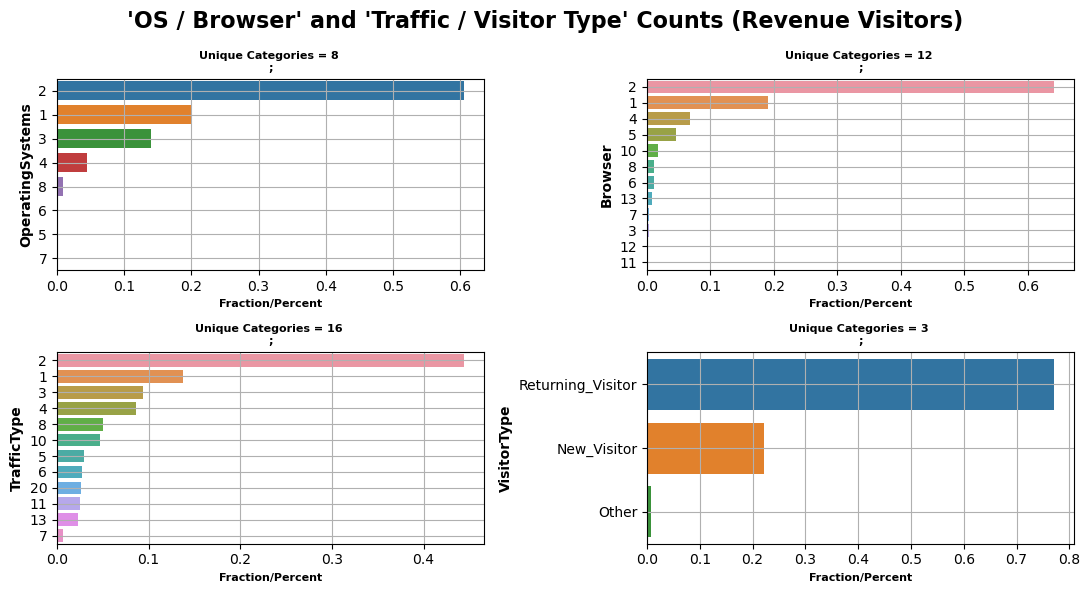

In [12]:
# Find Data Analysis for 'os_browser_grp' who generated 'Revenue'

fn_UVA_category(online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], os_browser_grp, 2, 2, 2)

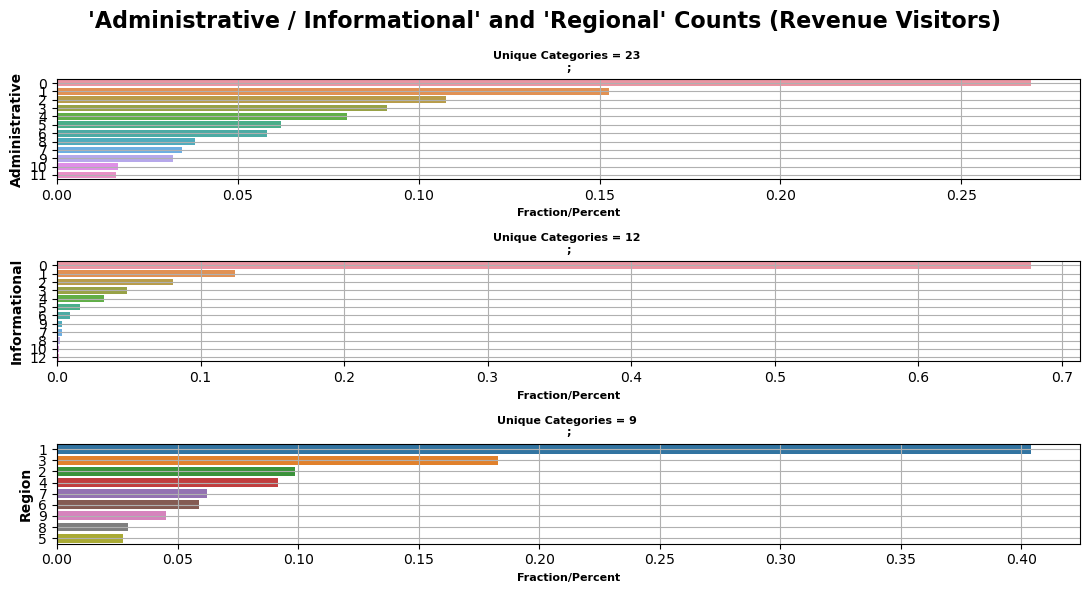

In [13]:
# Find Data Analysis for 'os_browser_grp' who generated 'Revenue'

fn_UVA_category(online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], admn_grp, 3, 1, 3)

### 4-b. Univariate analysis: Numerical Features<a id='4-b'></a>

In [14]:
# Numerical features of loaded 'Online_Shopper' Dataframe

online_shoppers_data_df.select_dtypes(include=['int64','int32','UInt32','float64','Int64']).dtypes

Administrative_Duration    float64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
dtype: object

In [15]:
# Create smaller subgroups

page_and_duration_grp = ['Administrative_Duration', 'Informational_Duration',
                         'ProductRelated','ProductRelated_Duration']
rates_and_value_grp   = ['BounceRates','ExitRates','PageValues']

In [16]:
# Function to perform Univariate Analysis for Numerical Features

def fn_UVA_numeric(data, var_group, row, col, default = -1):
    '''
    Univariate_Analysis_numeric
    takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

    Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
    '''

    size = len(var_group)
    fig, axs = plt.subplots(row, col, figsize=(15, 10), dpi = 140)
    if default == 1:
        fig.suptitle("'Administrative / Informational Duration' and 'Product Related Duration' (Revenue Visitors)", 
                     fontsize = 18, fontweight = 'bold')
    elif default == 2:
        fig.suptitle("'Bounce / Exit Rate' and 'Page Values' (Revenue Visitors)", 
                     fontsize = 18, fontweight = 'bold')
    

    for i, ax in enumerate(axs.flatten()):
        
        #----------------------------------------------------------------------------------------
        # Calculating descriptives of variable
        #----------------------------------------------------------------------------------------
        col    = var_group[i]
        mini   = data[col].min()
        maxi   = data[col].max()
        ran    = data[col].max()-data[col].min()
        mean   = data[col].mean()
        median = data[col].median()
        mode   = data[col].mode()
        st_dev = data[col].std()   
        skew   = data[col].skew()
        kurt   = data[col].kurtosis()
        #----------------------------------------------------------------------------------------
        # Calculating points of for range within One Standard Deviation
        #----------------------------------------------------------------------------------------
        points = mean-st_dev, mean+st_dev
        # Plotting the variables
        #----------------------------------------------------------------------------------------
        sns.kdeplot(x=data[col], fill=True, ax = ax)
        sns.lineplot(x=points, y=[0,0], color = 'black', label = "Within 1 Std_Dev", lw = 4, ax = ax)
        sns.scatterplot(x=[mini,maxi], y=[0,0], color = 'orange', label = "Min/Max", s = 150, ax = ax)
        sns.scatterplot(x=[mean], y=[0], color = 'red', label = "Mean", s = 150, ax = ax)
        sns.scatterplot(x=[median], y=[0], color = 'blue', label = "Median", s = 150, ax = ax)
        ax.set_xlabel(ax.get_xlabel(), fontsize = 12, fontweight = 'bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize = 12, fontweight = 'bold')
        ax.grid(True)
        ax.set_title('\nSpread for 1st Std_Dev = {}; Std. Deviation = {} \n Kurtosis = {}; Skew = {}; Range = {} \n Mean = {}; Median = {} \n'.format(
            (round(points[0],2),round(points[1],2)), round(st_dev,2), round(kurt,2), round(skew,2), 
            (round(mini,2),round(maxi,2),round(ran,2)), round(mean,2), round(median,2)))
        
    plt.tight_layout()

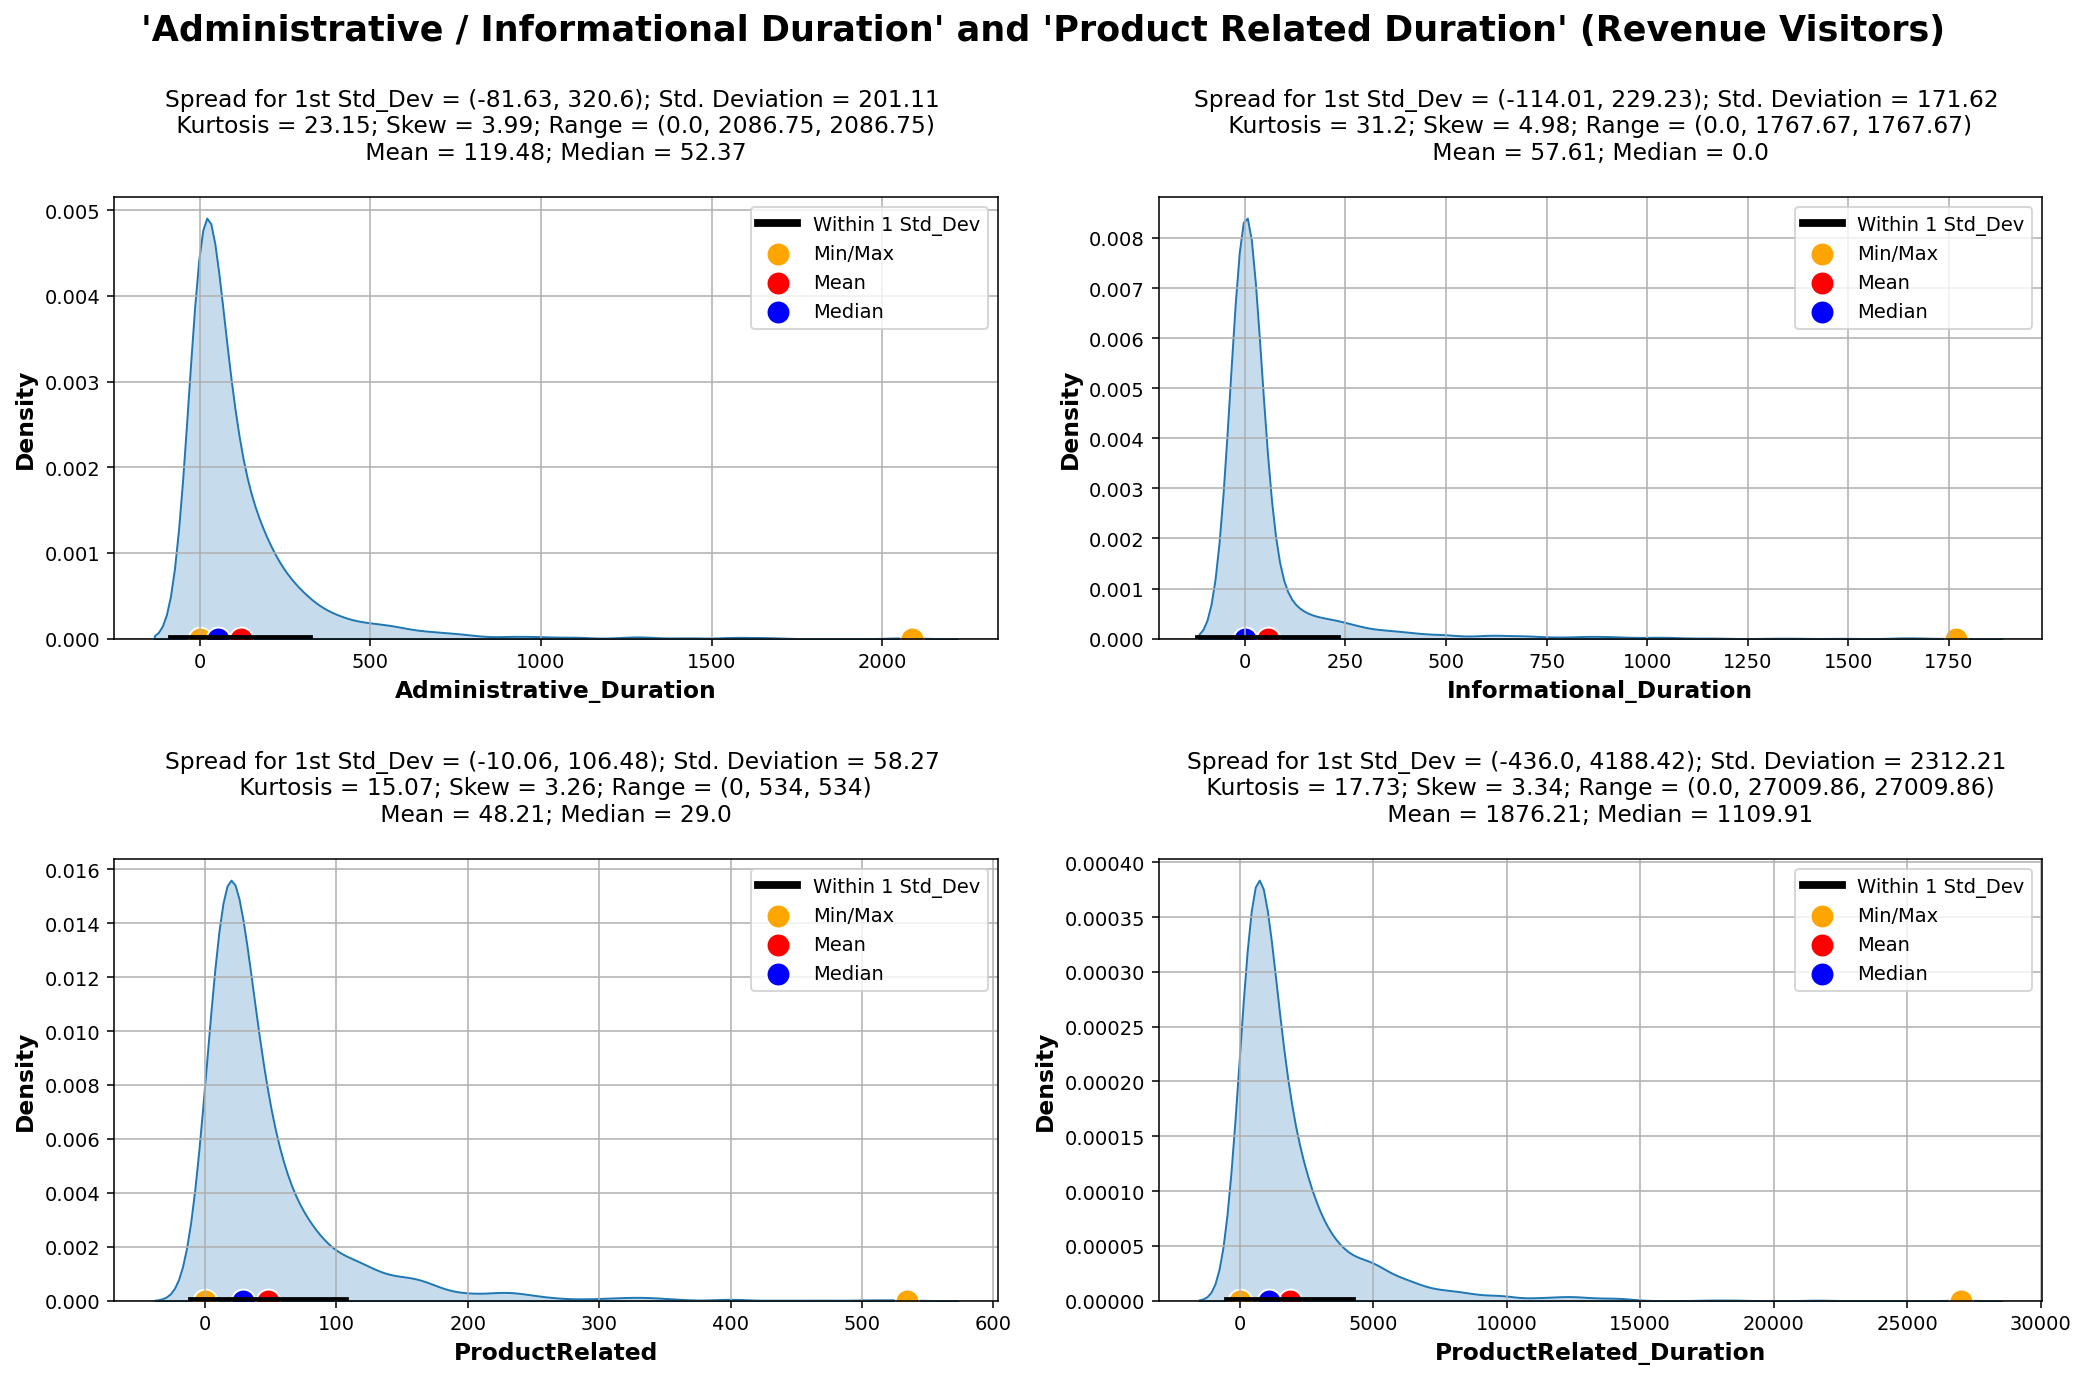

In [17]:
# Find the Numerical Features Distribution for the 'Revenue' Visitors

fn_UVA_numeric(online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], page_and_duration_grp, 2, 2, 1)

**Skewness**
    <br>-0.5 to -0.5 --> Symmetric
    <br>< -0.5 --> Negatively Skewed
    <br>\> 0.5 --> Positively Skewed

**Kurtosis**
    <br>k = 0 --> Mesokurtic    (Tais similar to Normal Distribution)
    <br>k > 0 --> Leptokurtic  (Longer Distribution  / fatter tail)
    <br>k < 0 --> Playtykurtic (Shorter Distribution / thinner tail)
    
**Skewness observed for `'Project-SVM' Dataset:`**

- Administrative           --> Postive / Right Skewed
- Administrative_Duration  --> Postive / Right Skewed
- Informational            --> Postive / Right Skewed
- Informational_Duration   --> Postive / Right Skewed

**Understanding Skewness and the Need for Transformation**
Skewness is a statistical measure that describes the asymmetry of a data distribution around its mean. In simpler terms, it indicates whether the bulk of the data is bunched up on one side of the scale, leaving a long tail stretching out in the opposite direction. There are two types of skewness you encounter in data analysis:

**Positive Skewness:** This occurs when the tail of the distribution extends towards higher values, on the right side of the peak. The majority of data points are clustered at the lower end of the scale, indicating that while most values are relatively low, there are a few exceptionally high values.

**Negative Skewness:** Conversely, negative skewness happens when the tail of the distribution stretches towards lower values, on the left side of the peak. In this scenario, the data is concentrated towards the higher end of the scale, with fewer values trailing off into lower numbers.

**Strategies for Taming `Positive Skewness`**

To combat positive skew, you can use five key transformations: Log, Square Root, Box-Cox, Yeo-Johnson, and Quantile Transformations. Each method aims to mitigate skewness, enhancing the data’s suitability for further analysis.

- **`Log Transformation`**
This method is particularly suited for right-skewed data, effectively minimizing large-scale differences by taking the natural log of all data points. This compression of the data range makes it more amenable for further statistical analysis.

- **`Square Root Transformation`**
A softer approach than the log transformation, ideal for moderately skewed data. By applying the square root to each data point, it reduces skewness and diminishes the impact of outliers, making the distribution more symmetric.

- **`Box-Cox Transformation`**
Offers flexibility by optimizing the transformation parameter lambda (λ), applicable only to positive data. The Box-Cox method systematically finds the best power transformation to reduce skewness and stabilize variance, enhancing the data’s normality.

- **`Yeo-Johnson Transformation`**
The above transformations only work with positive data. Yeo-Johnson is similar to Box-Cox but adaptable to both positive and non-positive data. It modifies the data through an optimal transformation parameter. This adaptability allows it to manage skewness across a wider range of data values, improving its fit for statistical models.

- **`Quantile Transformation`**
Quantile transformation maps data to a specified distribution, such as normal, effectively addresses skewness by distributing the data points evenly across the chosen distribution. This transformation normalizes the shape of the data, focusing on making the distribution more uniform or Gaussian-like without assuming it will directly benefit linear models due to its non-linear nature and the challenge of reverting the data to its original form.

**Strategies for Taming `Negative Skewness`**

To combat negative skew, you can use the five key transformations: Squared, Cubed, Box-Cox, Yeo-Johnson, and Quantile Transformations. Each method aims to mitigate skewness, enhancing the data’s suitability for further analysis.

- **`Squared Transformation`**
This involves taking each data point in the dataset and squaring it (i.e., raising it to the power of 2). The squared transformation is useful for reducing negative skewness because it tends to spread out the lower values more than the higher values. However, it’s more effective when all data points are positive and the degree of negative skewness is not extreme.

- **`Cubed Transformation`**
Similar to the squared transformation but involves raising each data point to the power of 3. The cubed transformation can further reduce negative skewness, especially in cases where the squared transformation is insufficient. It’s more aggressive in spreading out values, which can benefit more negatively skewed distribution

- **`Box-Cox Transformation`**
A more sophisticated method that finds the best lambda (λ) parameter to transform the data into a normal shape. The transformation is defined for positive data only. The Box-Cox transformation is highly effective for a wide range of distributions, including those with negative skewness, by making the data more symmetric. For negatively skewed data, a positive lambda is often found, applying a transformation that effectively reduces skewness.


#### Summary ('page_and_duration_grp')

- Administrative
    - The Revenue Visitors visited Administrative Page in ranges between 0 and 26
    - The 68% of Revenue Visitors visited Administrative Page Count between 0 - 7 (1st Std Dev.)
    - The Administratie Page Average Visisted Count is 3.39 and Median Count is 2.0 
    - The Distribution is 'Right Skewed' has Mean Value is Greater than Median
- Administrative Duration
    - Thej mean duration for the Admin page is 119.48 Seconds
    - The 68% of Revenue Visitors spent ~320 seconds
    - The Min & Max Admin duration Range is 0 - 2087 Seconds
    - The Distribution is 'Right Skewed' has Mean Value is Greater than Median
- Informational
    - The Revenue Visitors visited Informational Page in ranges between 0 and 12
    - The 68% of Revenue Visitors visited Informational Page Count between -0.74 - 2.31 (1st Std Dev.)
    - The Informational Page Average Visisted Count is 3.39 and Median Count is 0.79 
    - The Distribution is 'Right Skewed' has Mean Value is Greater than Median
- Informational Duration
    - Thej mean duration for the Informational page is 57.61 Seconds
    - The 68% of Revenue Visitors spent ~320 seconds
    - The Min & Max Admin duration Range is 0 - 1767 Seconds
    - The Distribution is 'Right Skewed' has Mean Value is Greater than Median

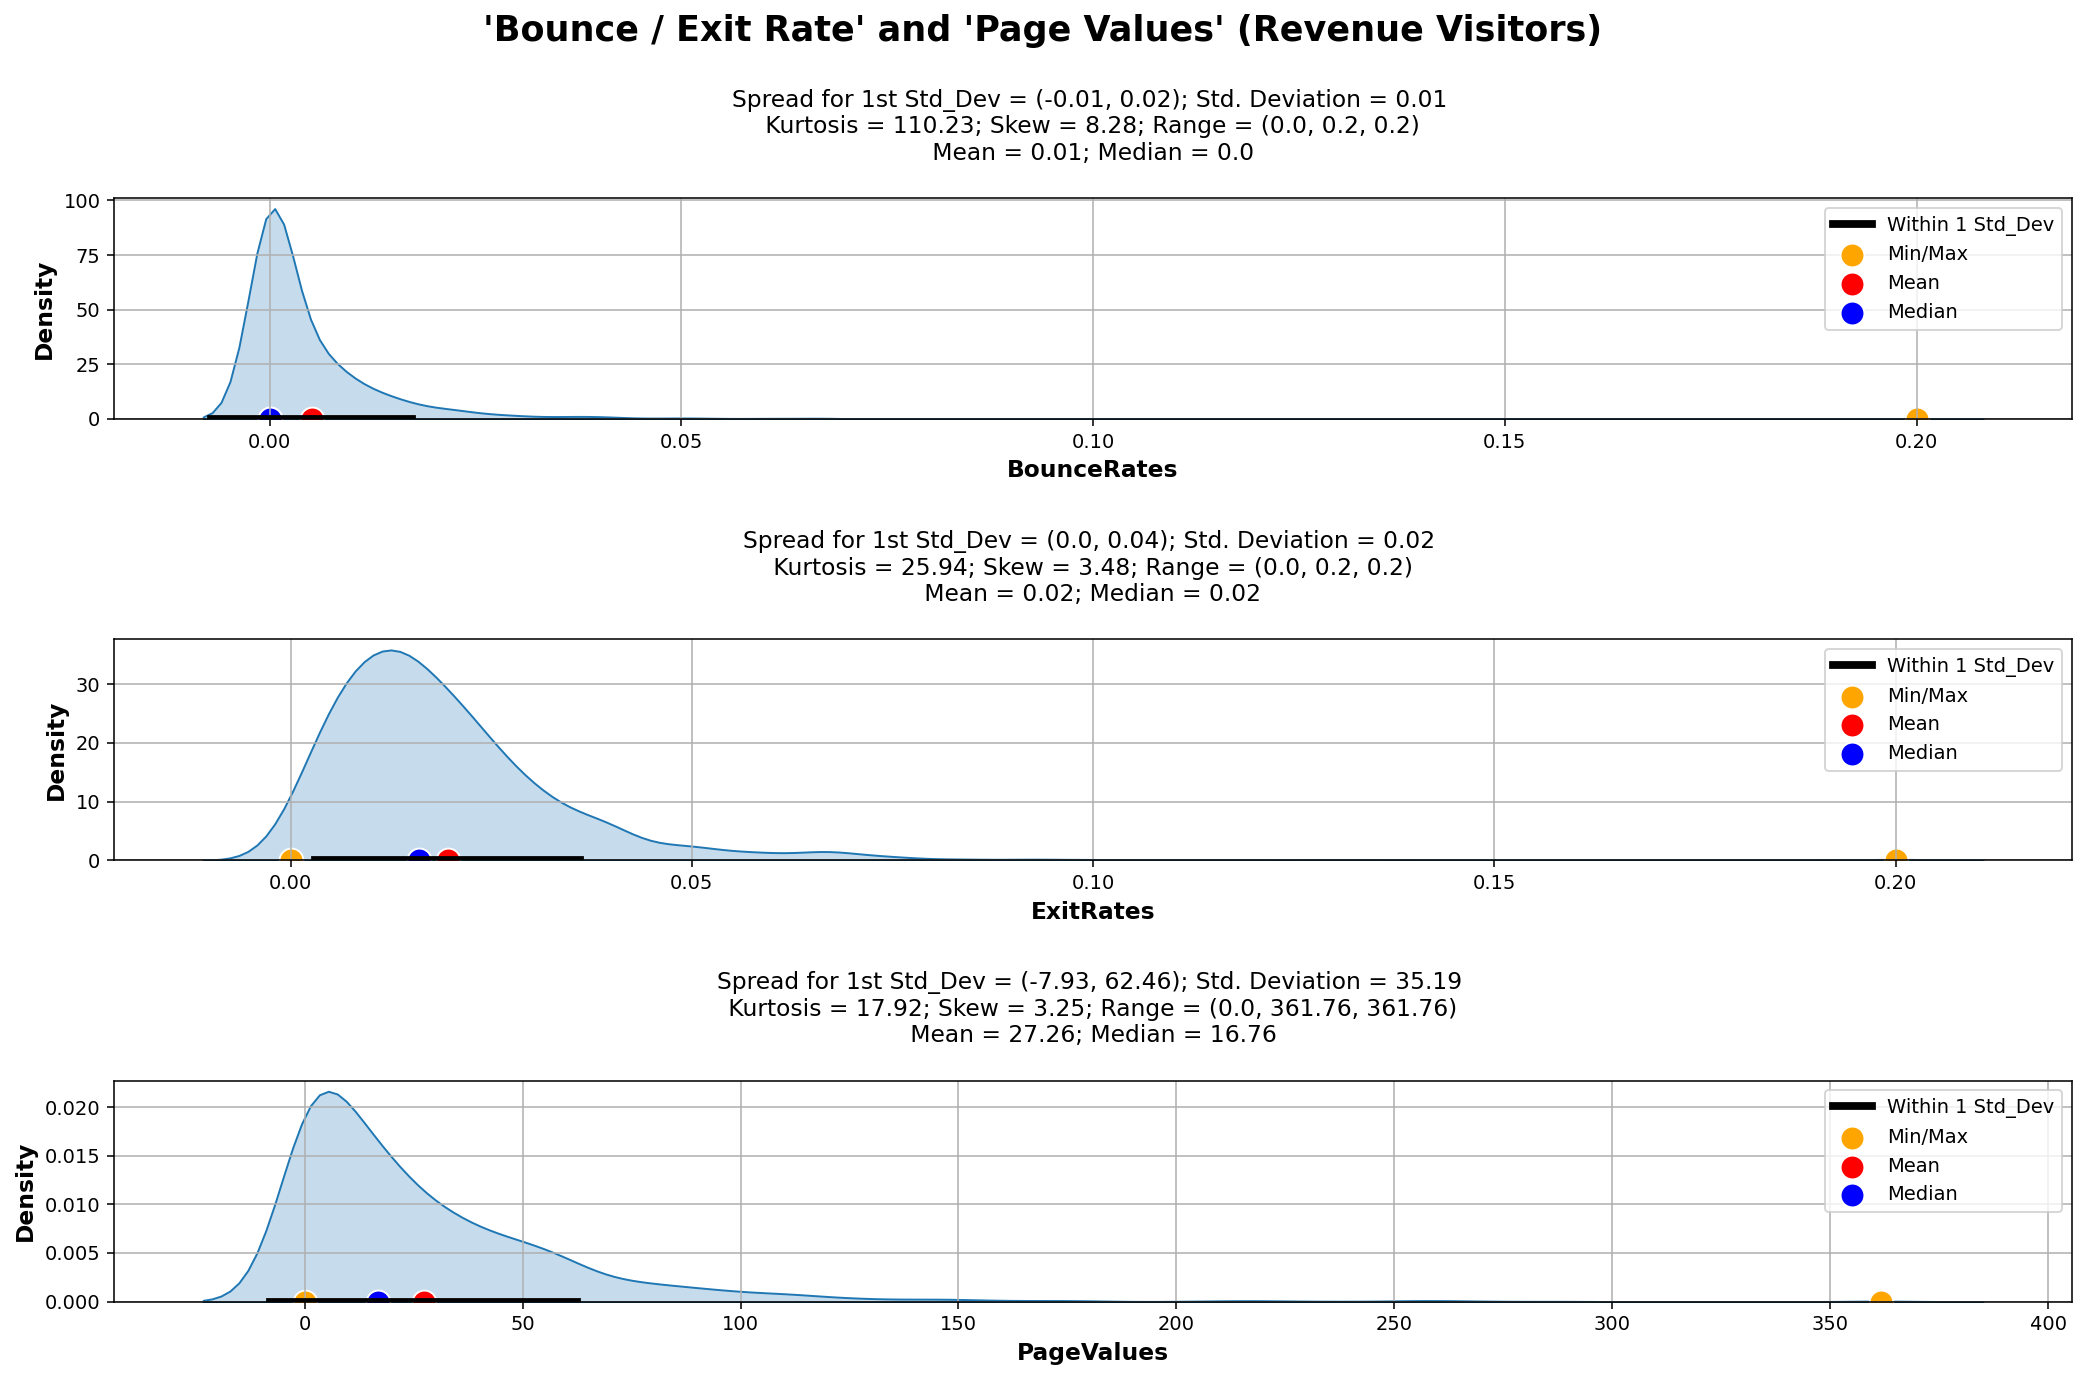

In [18]:
# Find the Numerical Features Distribution for the 'Revenue' Visitors

fn_UVA_numeric(online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], rates_and_value_grp, 3, 1, 2)

**Skewness**
    <br>-0.5 to -0.5 --> Symmetric
    <br>< -0.5 --> Negatively Skewed
    <br>\> 0.5 --> Positively Skewed

**Kurtosis**
    <br>k = 0 --> Mesokurtic    (Tais similar to Normal Distribution)
    <br>k > 0 --> Leptokurtic  (Longer Distribution  / fatter tail)
    <br>k < 0 --> Playtykurtic (Shorter Distribution / thinner tail)

**Skewness observed for `'Project-SVM' Dataset:`**

- BounceRates          --> Postive / Right Skewed
- ExitRates  --> Postive / Right Skewed
- PageValues            --> Postive / Right Skewed
- SpecialDay   --> Postive / Right Skewed

#### Summary ('rates_and_value_grp')

- Bounce Rates
    - The Revenue Visitors visited Bounce Rate in ranges between 0 and 0.2
    - The 68% of Revenue Visitors visited Bounce Rate between -0.01 - 0.02 (1st Std Dev.)
    - The  Average Visisted Bounce RAte is 0.01 and Median Count is 0. 
    - The Distribution is 'Right Skewed' has Mean Value is Greater than Median
- Administrative Duration
    - There seems to be short trip duration having most of the frequency density
- Informational
    - The most of the distance is aorund short range or up to 25 miles in range
    - There are no significant distributio found beyond 25 mile range 

### 4-c. Univariate analysis: Any Potential Outliers<a id='4-c'></a>

In [19]:
# Function to figure out any potential outliers

def fn_UVA_outlier(data, var_group, row, col, default = -1):
    '''
    Univariate_Analysis_outlier:
    takes a group of variables (INTEGER and FLOAT) and plot/print boplot and descriptives\n
    Runs a loop: calculate all the descriptives of i(th) variable and plot/print it \n\n

    data : dataframe from which to plot from\n
    var_group : {list} type Group of Continuous variables\n
    include_outlier : {bool} whether to include outliers or not, default = True\n
    '''
    #------------------------------------------------------------------------------------------
    fig, axs = plt.subplots(row, col, figsize=(12, 6))
    #------------------------------------------------------------------------------------------
    if default == 1:
        fig.suptitle("'Number Of Times Page Visited' and 'Page Duration' (Revenue Visitors)", 
                     fontsize = 16, fontweight = 'bold')
    elif default == 2:
        fig.suptitle("'Bounce / Exit Rate' and 'Page Values' (Revenue Visitors)", 
                     fontsize = 16, fontweight = 'bold')
    elif default == 3:
        fig.suptitle("'OS / Browser' and 'Region / Traffic Type' (Revenue Visitors)", 
                     fontsize = 16, fontweight = 'bold')
    #------------------------------------------------------------------------------------------
    for i, ax in enumerate(axs.flatten()):
    #------------------------------------------------------------------------------------------
        col = var_group[i]
        quant25 = data[col].quantile(0.25)
        quant75 = data[col].quantile(0.75)
        IQR = quant75 - quant25
        med = data[col].median()
        whis_low = med - (1.5*IQR)
        whis_high = med + (1.5*IQR)
        #------------------------------------------------------------------------------------------
        # Calculating Number of Outliers
        #------------------------------------------------------------------------------------------
        outlier_high = len(data[col][data[col]>whis_high])
        outlier_low = len(data[col][data[col]<whis_low])
        sns.boxplot(data[col], orient="v", ax = ax)
        ax.set_xlabel(col)
        ax.set_xlabel(ax.get_xlabel(), fontsize = 12, fontweight = 'bold')
        ax.set_ylabel(col)
        ax.set_ylabel(ax.get_ylabel(), fontsize = 12, fontweight = 'bold')
        ax.set_title('With Outliers\nIQR = {}; Median = {} \n 2nd,3rd  quartile = {};\n Outlier (low/high) = {} \n'.format(
            round(IQR,2), round(med,2), (round(quant25,2),round(quant75,2)), (outlier_low,outlier_high)))
    
    plt.tight_layout()
    plt.show()

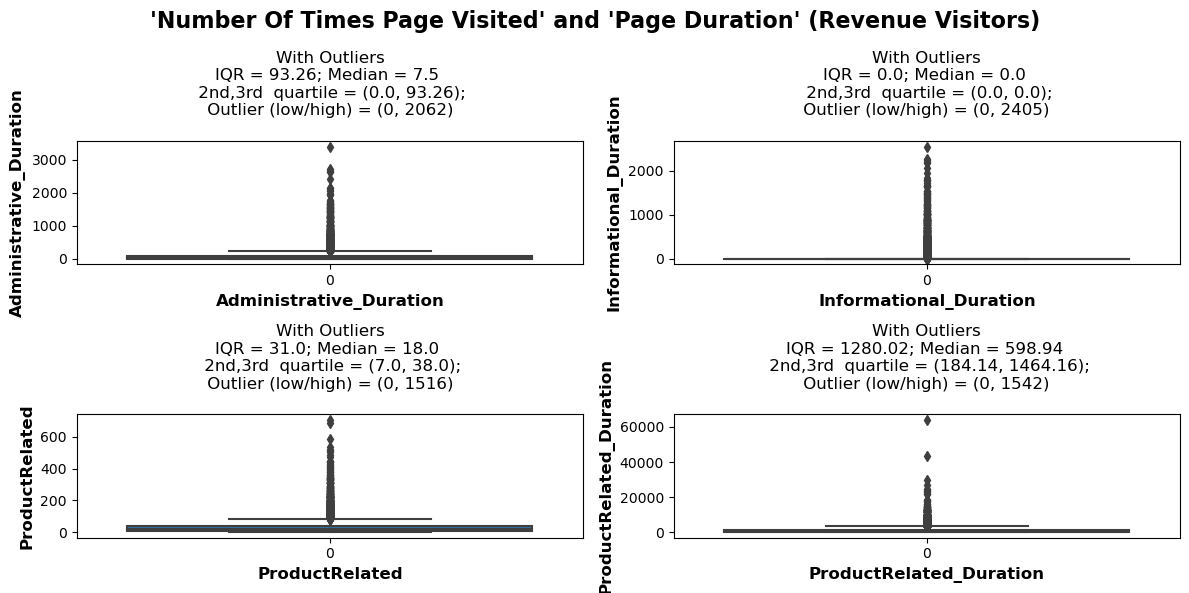

In [20]:
fn_UVA_outlier(online_shoppers_data_df, page_and_duration_grp,2,2,1)

####  Summary
- Week of Year
    - The most frequency range seem to be6 - 20 weeeks
    - There is an outlier values of 55 that needs to be evaluated
- Month of Year
    - The most frequency seem to be month 2 - 5
    - No outliers value observed

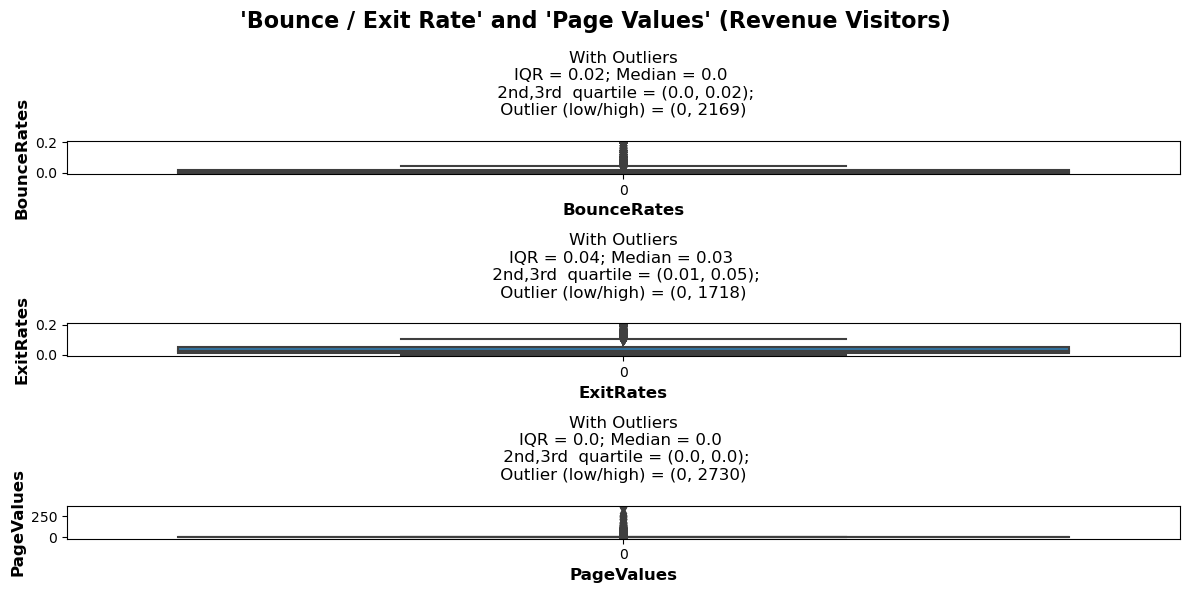

In [21]:
fn_UVA_outlier(online_shoppers_data_df, rates_and_value_grp, 3,1,2)

####  Summary
- Week of Year
    - The most frequency range seem to be6 - 20 weeeks
    - There is an outlier values of 55 that needs to be evaluated
- Month of Year
    - The most frequency seem to be month 2 - 5
    - No outliers value observed

## 5. Feature Realtionships (Bivariate Analysis)<a id='5'></a>

### 5.a Bivariate Analysis : Numerical-Numerical<a id='5.a'></a>

In [22]:
# Create Dataframe of all numerical feaures and also make subgroups of numerical features

numerical_all_features_df = online_shoppers_data_df.select_dtypes(include = ['int64', 'float64', 'int32', 'UInt32'])

In [23]:
# Compute Correlation Matrix

correlation = numerical_all_features_df.corr()
correlation.reset_index(inplace = True)
correlation.head(10)

,index,Administrative_Duration,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues
0,Administrative_Duration,1.000000,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608
1,Informational_Duration,0.238031,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861
2,ProductRelated,0.289087,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282
3,ProductRelated_Duration,0.355422,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823
4,BounceRates,-0.144170,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386
5,ExitRates,-0.205798,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498
6,PageValues,0.067608,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000


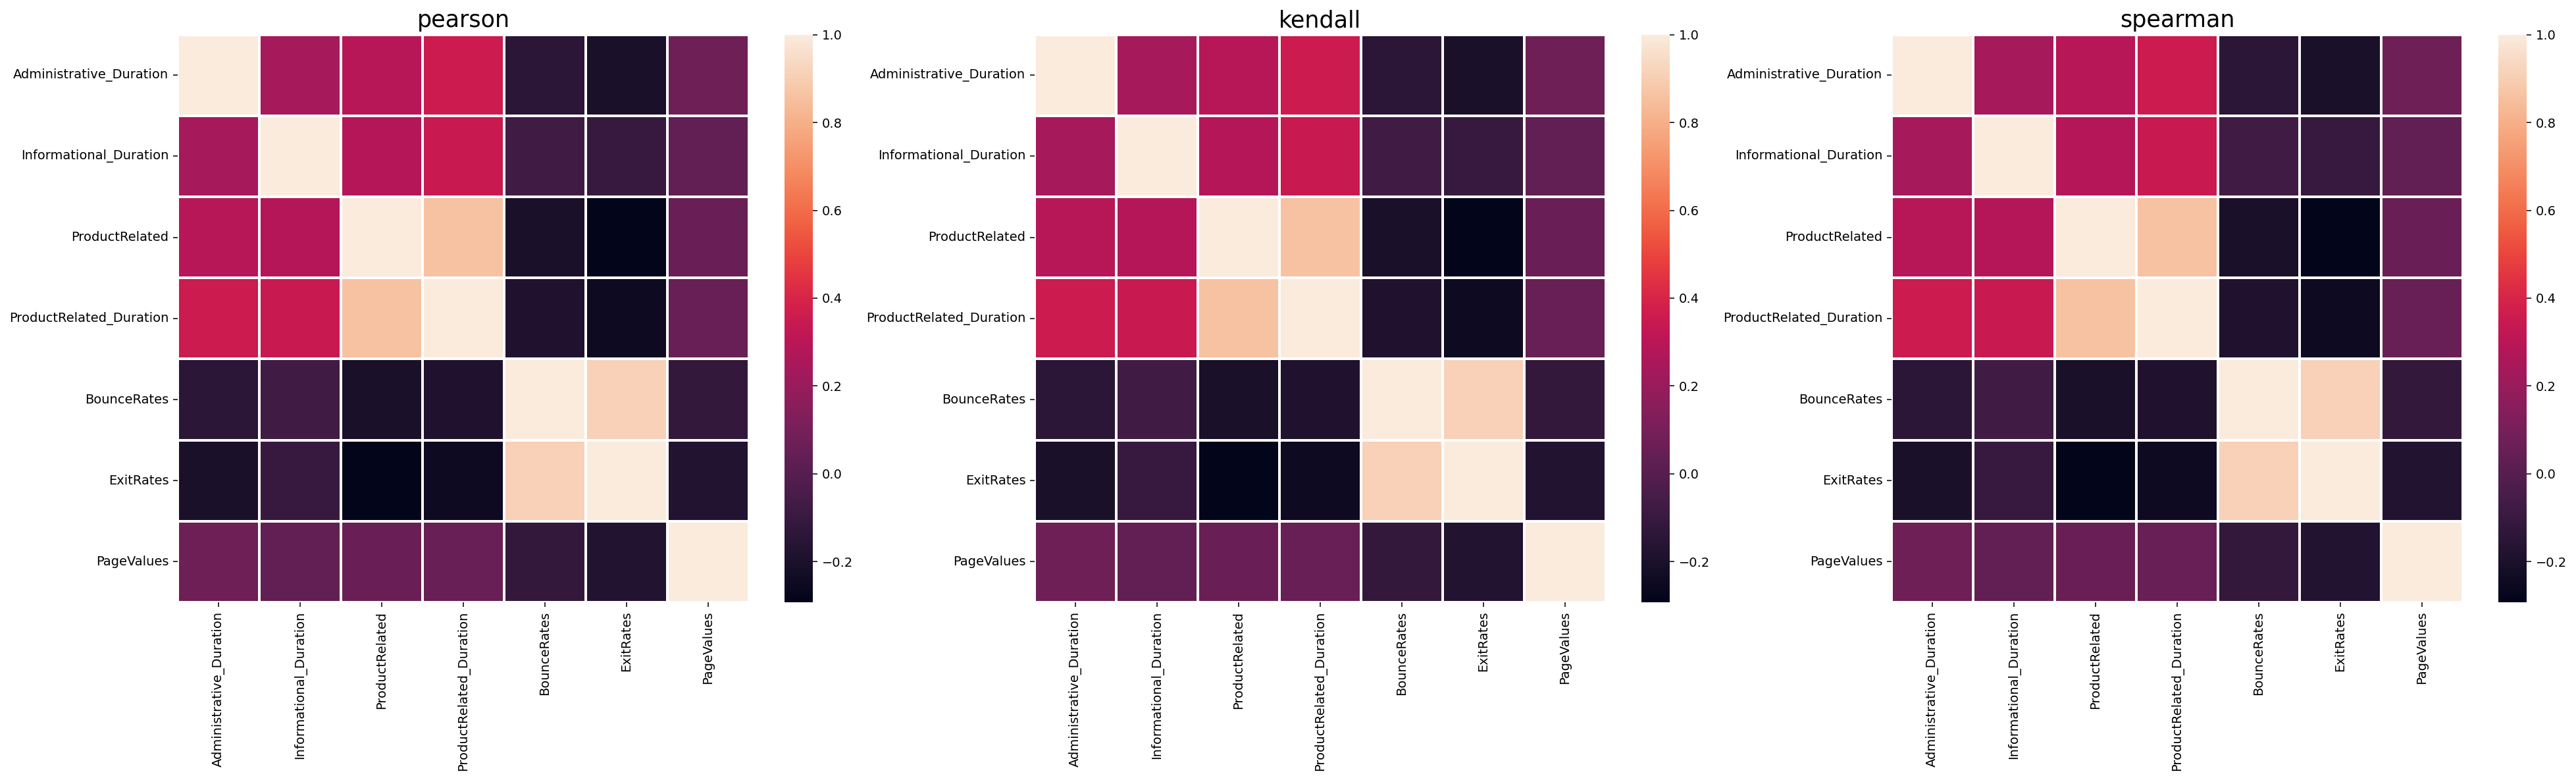

In [24]:
# Plot Heatmap using all numerical features

plt.figure(figsize=(34,8), dpi=140)
for j,i in enumerate(['pearson','kendall','spearman']):
  plt.subplot(1,3,j+1)
  correlation = numerical_all_features_df.corr()
  sns.heatmap(correlation, linewidth = 2)
  plt.title(i, fontsize=18)

In [25]:
numerical_all_features = online_shoppers_data_df.select_dtypes(include = ['int64', 'float64', 'int32', 'UInt32']).dtypes

In [26]:
numerical_all_features

Administrative_Duration    float64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
dtype: object

In [27]:
admin_prod_duration = ['Administrative_Duration','Informational_Duration','ProductRelated','ProductRelated_Duration']
bounce_exit_rates   = ['BounceRates','ExitRates','PageValues']
all_num_features    = admin_prod_duration + bounce_exit_rates

In [28]:
# scatter plot for a sample of transactional variables

# plt.figure()
# sns.pairplot(online_shoppers_data_df[all_num_features])

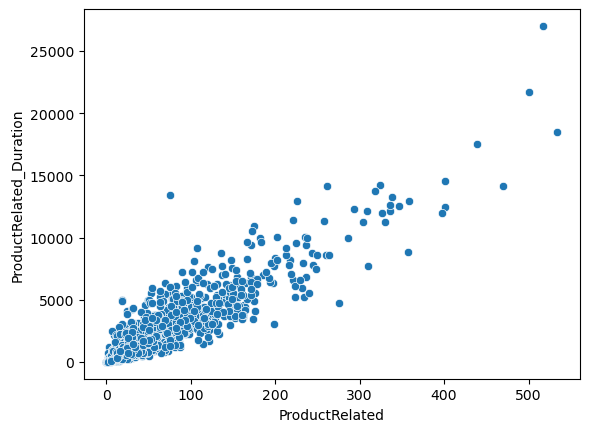

In [29]:
# Find relation beween 'Product Related' and 'Product Related Duration'

sns.scatterplot(data = online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], \
                x = 'ProductRelated', y = 'ProductRelated_Duration');

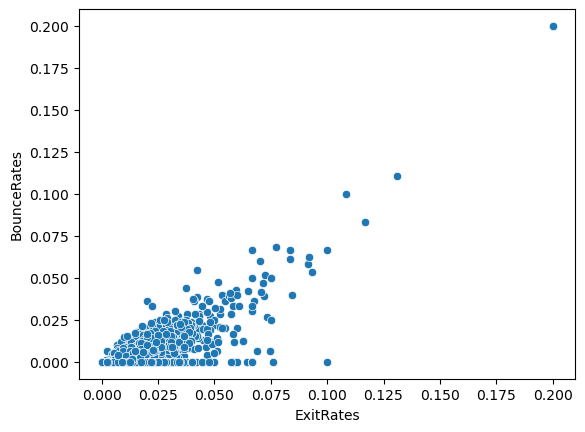

In [30]:
# Find relation between 'Exit Rates' and 'BounceRates'

sns.scatterplot(data = online_shoppers_data_df[online_shoppers_data_df['Revenue'] == True], \
                x = 'ExitRates', y = 'BounceRates');

### 5.b Bivariate Analysis : Continuous - Categorical<a id='5.b'></a>

In [31]:
# Helper Function to compute p-value

def fn_TwoSampZ(X1, X2, sigma1, sigma2, N1, N2):
  '''
  takes mean, standard deviation, and number of observations and returns p-value calculated for 2-sampled Z-Test
  '''
  from numpy import sqrt, abs, round
  from scipy.stats import norm
  ovr_sigma = sqrt(sigma1**2/N1 + sigma2**2/N2)
  z = (X1 - X2)/ovr_sigma
  pval = 2*(1 - norm.cdf(abs(z)))
  return pval

In [32]:
# Helper Function to perform 2-Sample T-Test

def fn_TwoSampT(X1, X2, sd1, sd2, n1, n2):
  '''
  takes mean, standard deviation, and number of observations and returns p-value calculated for 2-sample T-Test
  '''
  from numpy import sqrt, abs, round
  from scipy.stats import t as t_dist

  ovr_sd = sqrt(sd1**2/n1 + sd2**2/n2)
  t = (X1 - X2)/ovr_sd
  df = n1+n2-2
  pval = 2*(1 - t_dist.cdf(abs(t),df)), 
  return round(pval)

In [33]:
# Function to perform Bivariate Analysis for Continous Features

def fn_Bivariate_cont_cat(data, cont, cat, category1, category2):
    #creating 2 samples
    x1 = data[data[cat]==True][cont]
    x2 = data[data[cat]==False][cont]

    #calculating descriptives
    n1, n2 = x1.shape[0], x2.shape[0]
    m1, m2 = round(x1.mean(),2), round(x2.mean(), 2)

    std1, std2 = x1.std(), x2.std()

    #calculating p-values
    t_p_val = fn_TwoSampT(m1, m2, std1, std2, n1, n2)
    z_p_val = fn_TwoSampZ(m1, m2, std1, std2, n1, n2)


    #checking whether results are significant
    #print('t-value',type(t_p_val.astype(float)), 'p-value', z_p_val)
    if (t_p_val) or (z_p_val) < 0.05:
        sig = True
    else:
        sig = False

    #table
    table = pd.pivot_table(data=data, values=cont, columns=cat, aggfunc = np.mean)

    #plotting
    plt.figure(figsize = (10,5), dpi=140)

    #barplot
    plt.subplot(1,2,1)
    sns.barplot(data, x = [category1,category2], y = [m1, m2])
    #sns.barplot([str(category),'not {}'.format(category)], [m1, m2], hue = 'default')
    plt.ylabel('Mean {}'.format(cont))
    plt.xlabel(cat)
    plt.title('t-Test p-Value = {} \n z-Test p-Value = {} \n Difference Significant? = \
    {} \n\n {}\n'.format(np.round(t_p_val, 
                                                                                8), np.round(z_p_val, 8), sig, table))

    # plt.title(f"-Value = {round(p, 8)}\n Difference Significant? = {sig}\n", fontsize = 8, fontweight = 'bold')

    # boxplot
    plt.subplot(1,2,2)
    sns.boxplot(data, x=cat, y=cont)
    plt.title('Categorical Boxplot')

    plt.tight_layout()

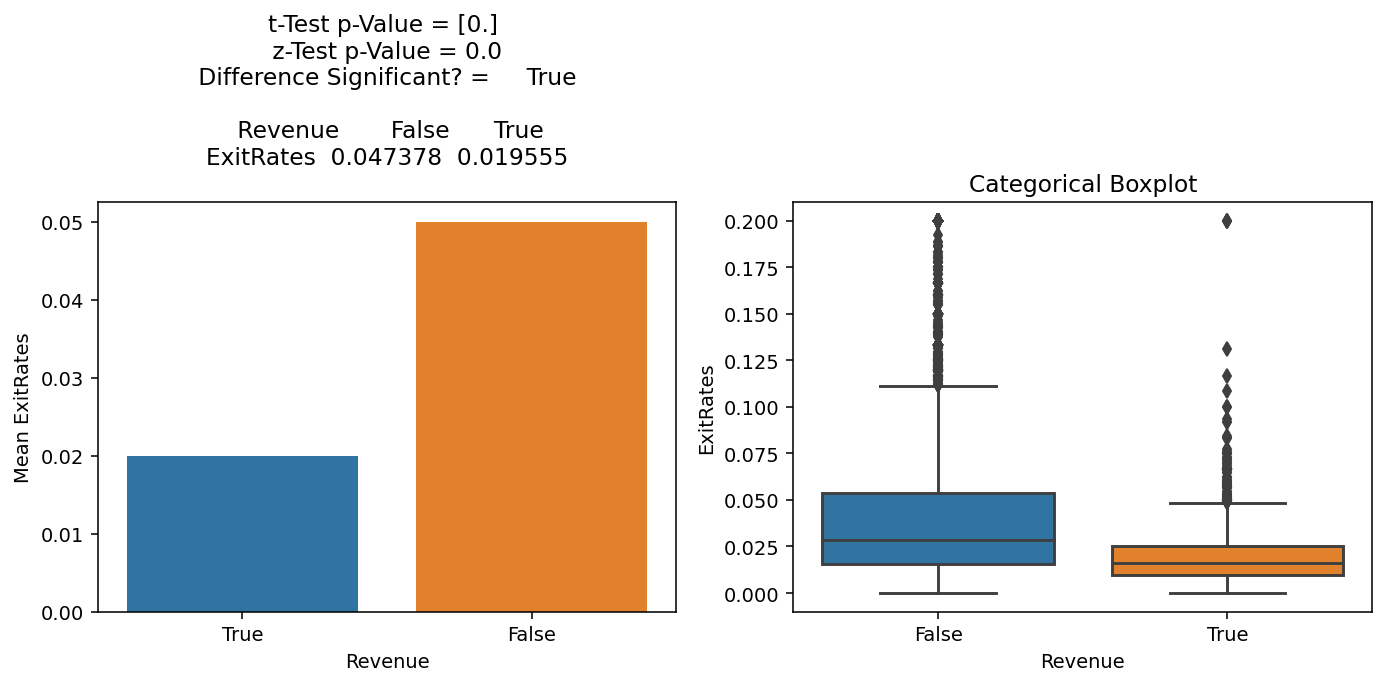

In [34]:
# Compare mean 'ExitRates' between 'True' and 'False' Revenue Customers

fn_Bivariate_cont_cat(online_shoppers_data_df, 'ExitRates', 'Revenue', 'True', 'False')

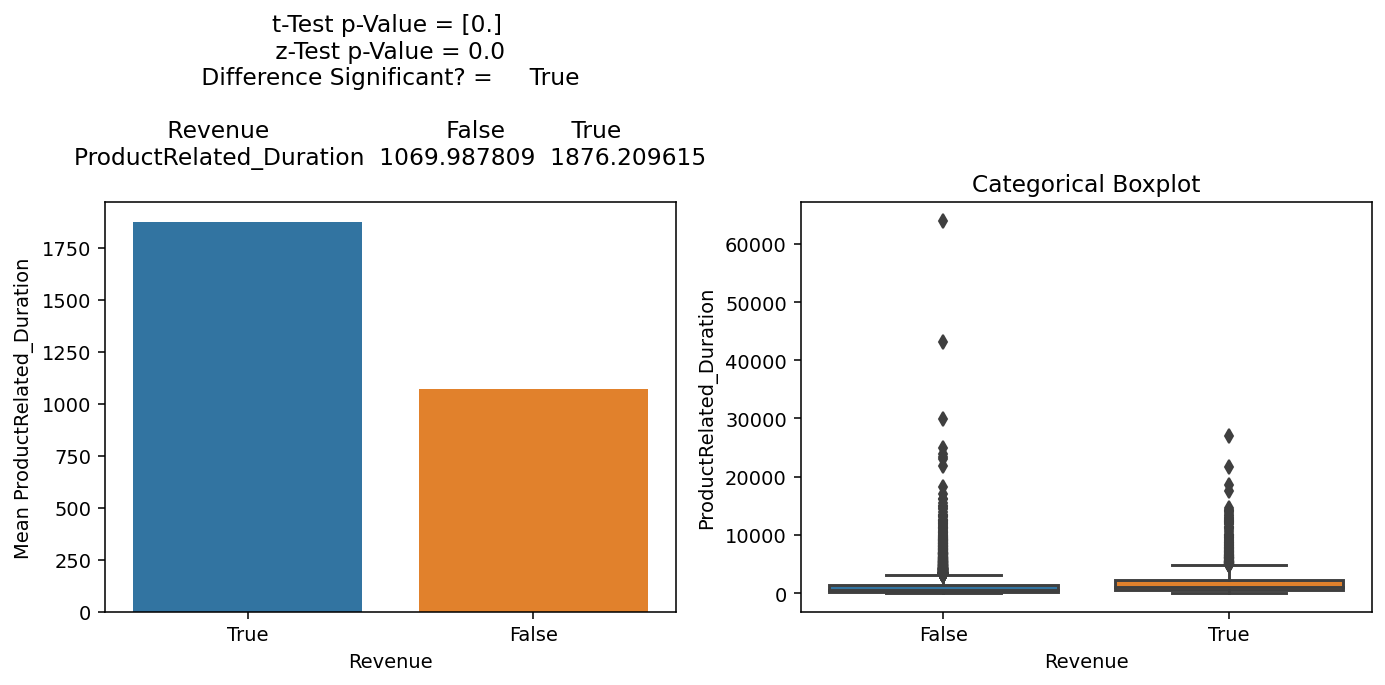

In [35]:
# Compare mean 'ProductRelated Duration' between 'True' and 'False' Revenue Customer

fn_Bivariate_cont_cat(online_shoppers_data_df, 'ProductRelated_Duration', 'Revenue', 'True', 'False')

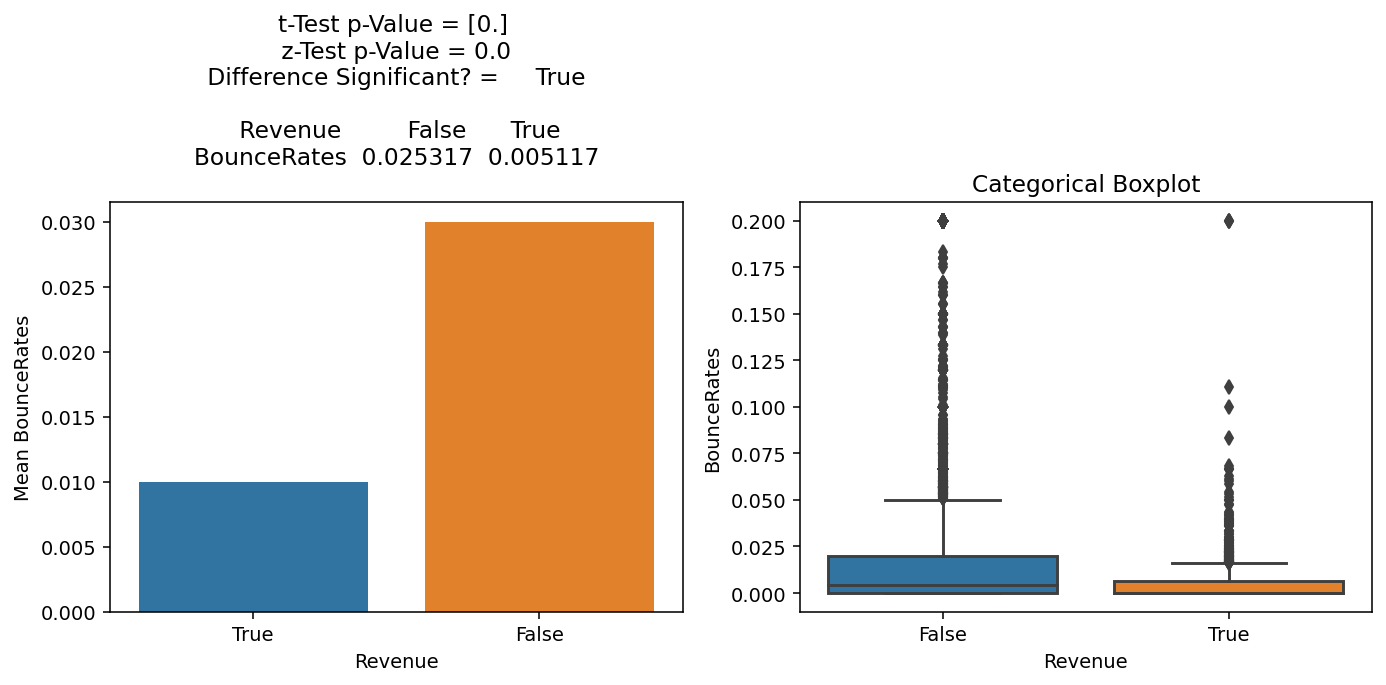

In [36]:
# Compare mean 'Bounce Rates' between 'True' and 'False' Revenue Customer

fn_Bivariate_cont_cat(online_shoppers_data_df, 'BounceRates', 'Revenue', 'True', 'False')

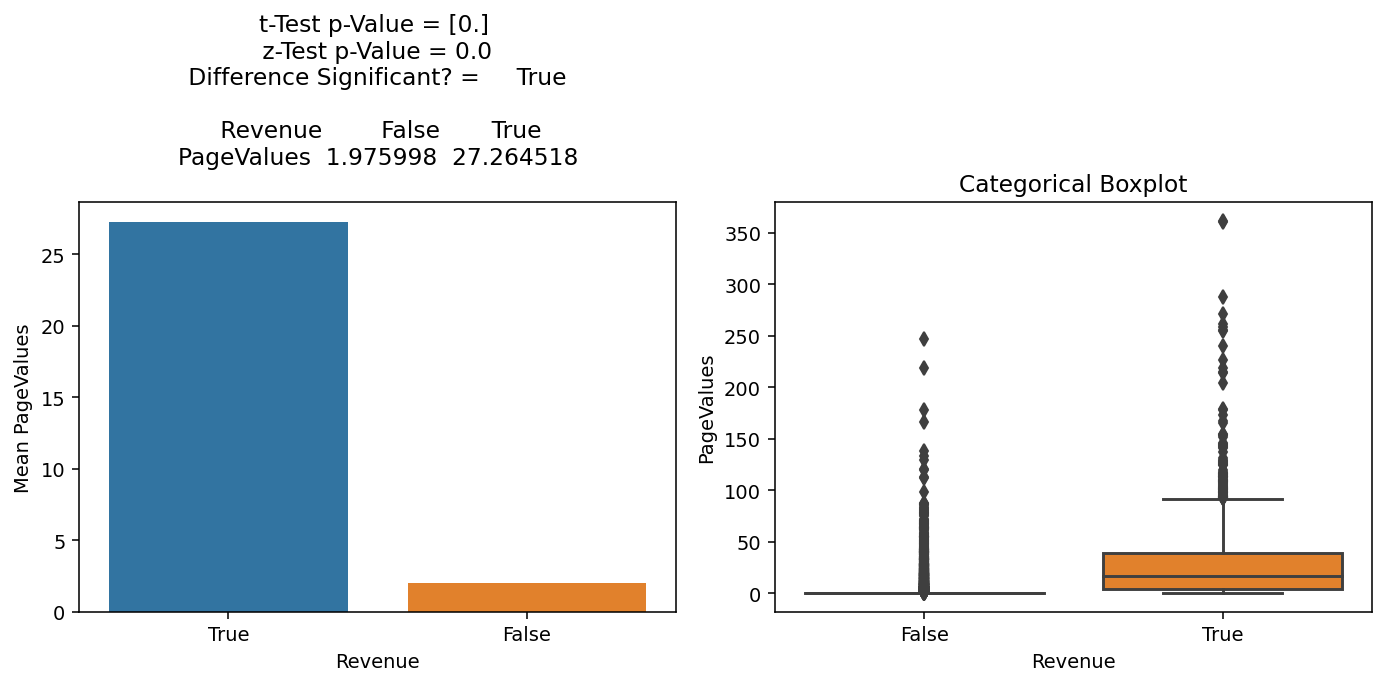

In [37]:
# Compare mean 'PageValues' between 'True' and 'False' Revenue Customer

fn_Bivariate_cont_cat(online_shoppers_data_df, 'PageValues', 'Revenue', 'True', 'False')

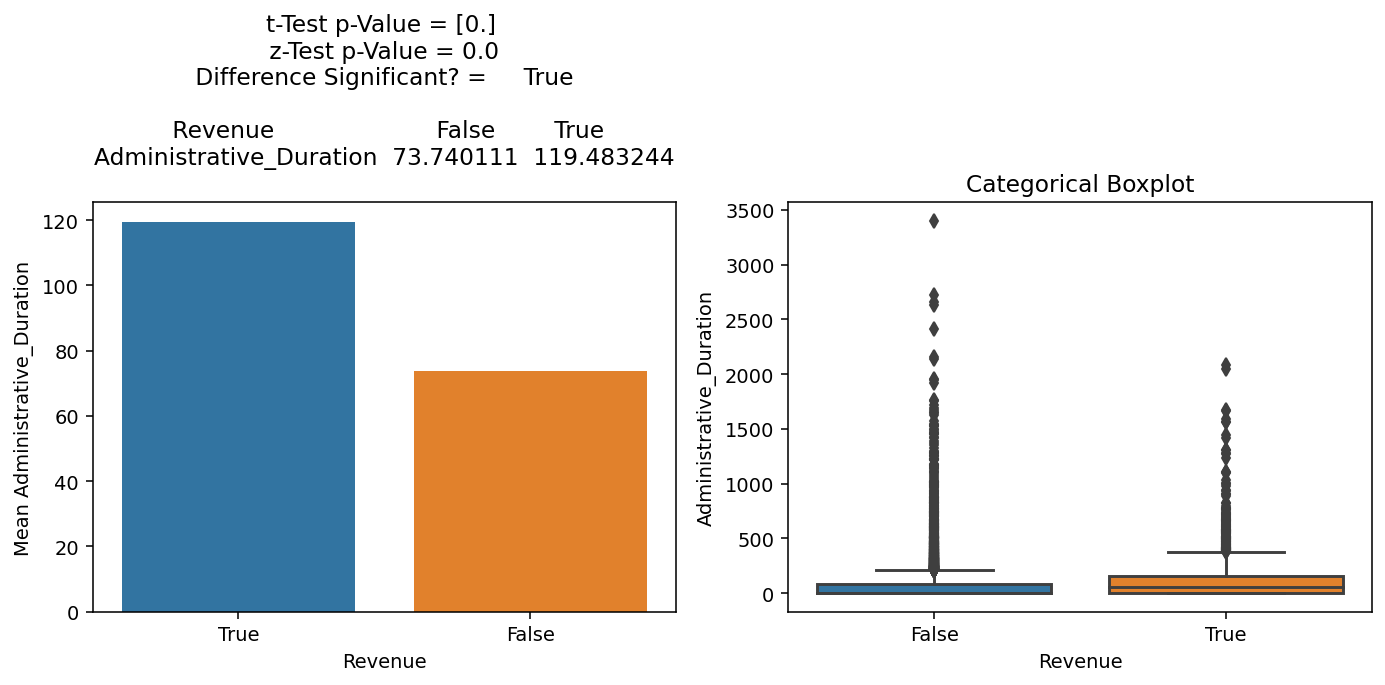

In [38]:
# Compare mean 'Administrative Duration' between 'True' and 'False' Revenue Customer

fn_Bivariate_cont_cat(online_shoppers_data_df, 'Administrative_Duration', 'Revenue', 'True', 'False')

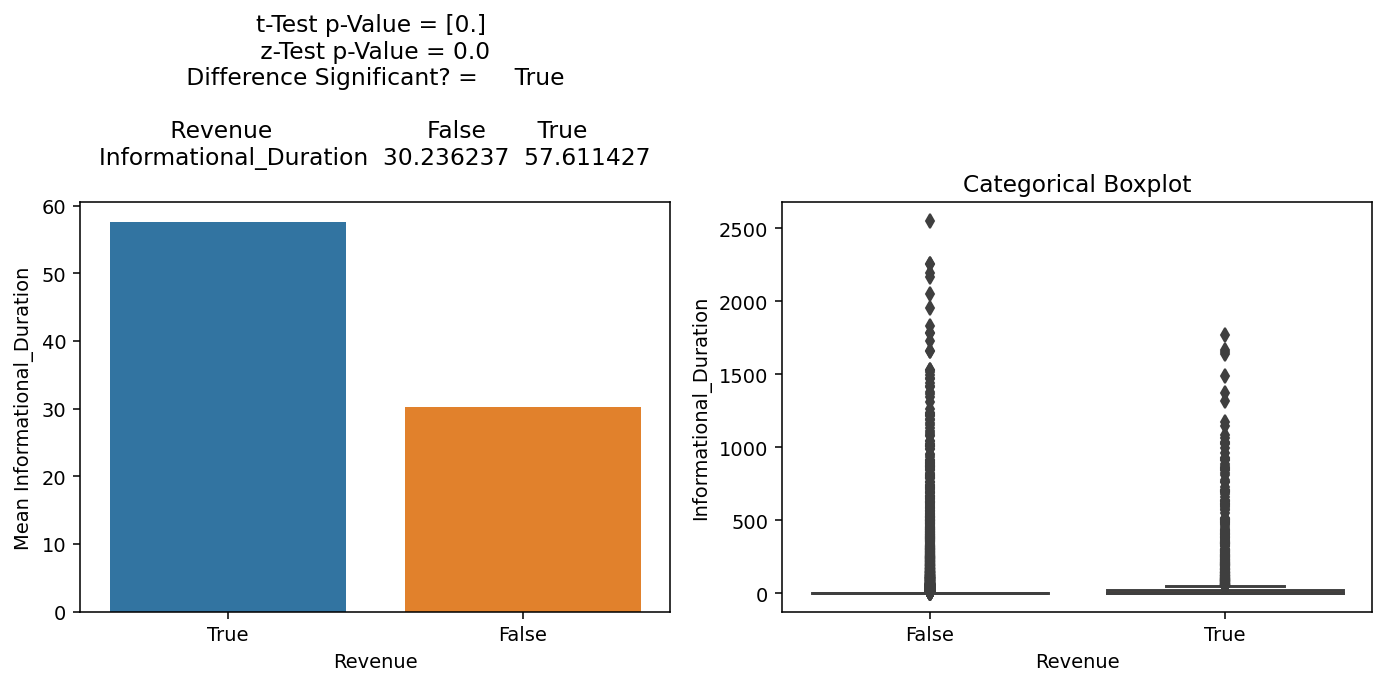

In [39]:
# Compare mean 'Informational_Duration' between 'True' and 'False' Revenue Customer

fn_Bivariate_cont_cat(online_shoppers_data_df, 'Informational_Duration', 'Revenue', 'True', 'False')

### 5.c Bivariate Analysis : Categorrical - Categorical<a id='5.c'></a>

In [40]:
# Function to perform Bivariate Analysis for Categorical Features

def fn_BVA_categorical_plot(data, tar, cat):
    '''
    take data and two categorical variables,
    calculates the chi2 significance between the two variables 
    and prints the result with countplot & CrossTab

    '''
    #isolating the variables
    data = data[[cat,tar]][:]

    #forming a crosstab
    table = pd.crosstab(data[tar],data[cat])
    f_obs = np.array([table.iloc[0][:].values, table.iloc[1][:].values])

    #performing chi2 test
    from scipy.stats import chi2_contingency
    chi, p, dof, expected = chi2_contingency(f_obs)

    #checking whether results are significant
    if p < 0.05:
        sig = True
    else:
        sig = False

    fig, ax = plt.subplots(figsize=(15,4), nrows=1, ncols=2)
    #plotting grouped plot
    sns.countplot(x = cat, hue = tar, data = data[data[cat] != 0],ax=ax[0])
    plt.title(f"p-Value = {round(p, 8)}\n Difference Significant? = {sig}\n", fontsize = 8, fontweight = 'bold')
    ax[0].set_xlabel(ax[0].get_xlabel(), fontsize = 12, fontweight = 'bold')
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, horizontalalignment='right')
    ax[0].set_ylabel(ax[0].get_ylabel(), fontsize = 12, fontweight = 'bold')
    
    #plotting percent stacked bar plot
    axs1 = pd.crosstab(data[cat], data[tar], normalize='index')
    ax[1] = axs1.plot(kind='bar', stacked='True',title=str(axs1),ax=ax[1])
    #sns.barplot(x = cat, y = tar, data = data,ax=ax[1])
    ax[1].set_xlabel(ax[1].get_xlabel(), fontsize = 12, fontweight = 'bold')
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, horizontalalignment='right')
    #ax[1].ylabel(ax.get_ylabel(), fontsize = 12, fontweight = 'bold') 

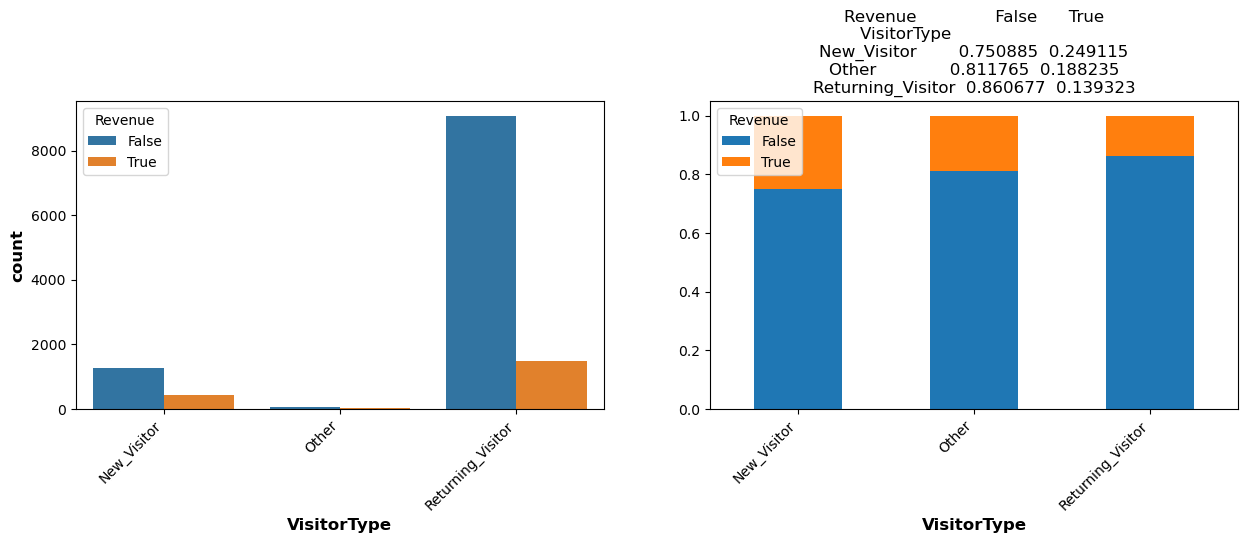

In [41]:
# Compute 'Revenue' Customers from 'VisotorType'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'VisitorType')

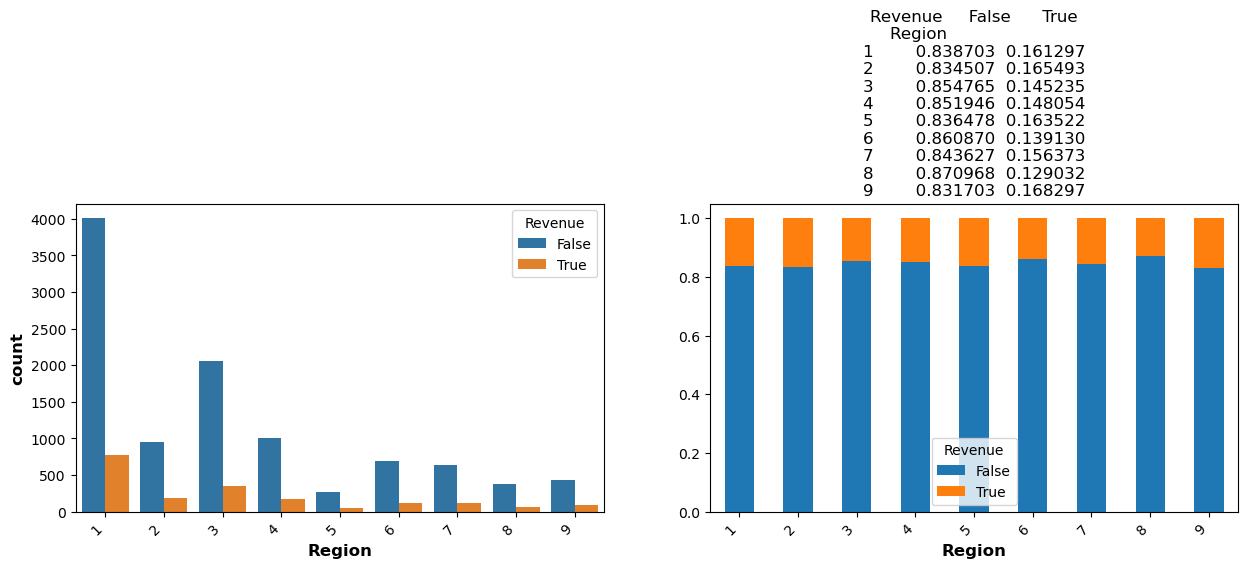

In [42]:
# Compute 'Revenue' Customers from 'Region'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'Region');

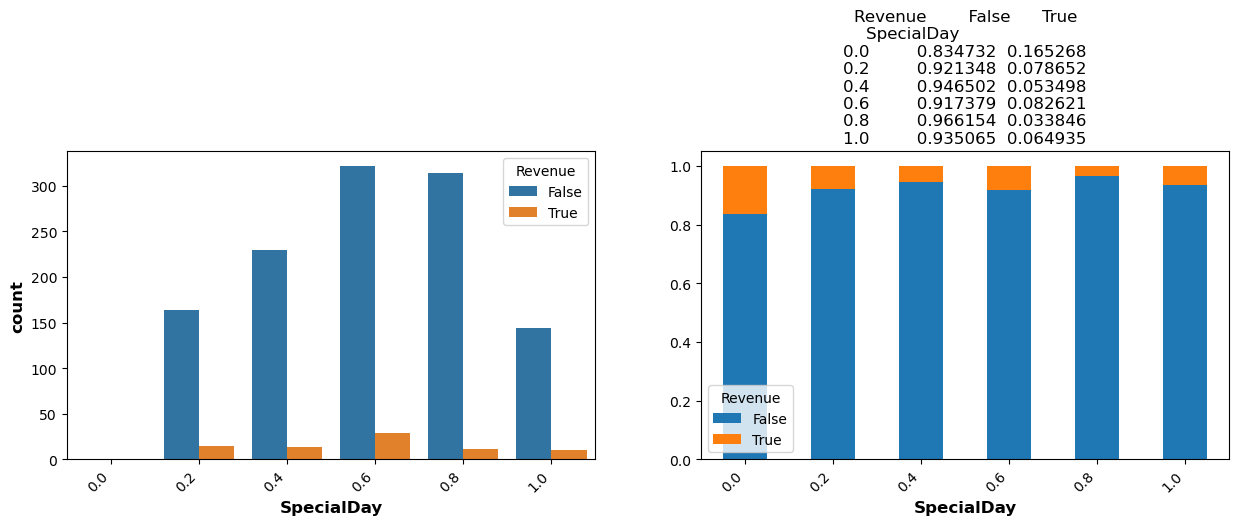

In [43]:
# Compute 'Revenue' Customers from 'Region'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'SpecialDay');

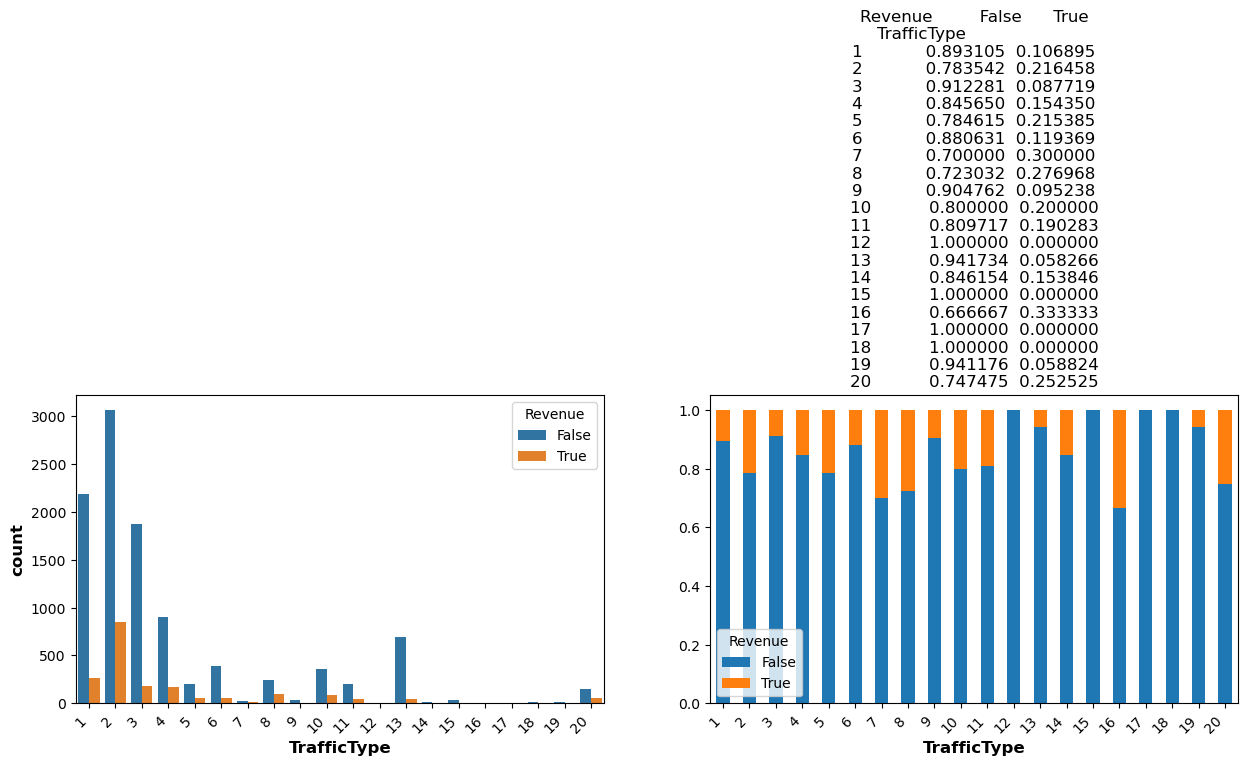

In [44]:
# Compute 'Revenue' Customers from 'TrafficType'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'TrafficType');

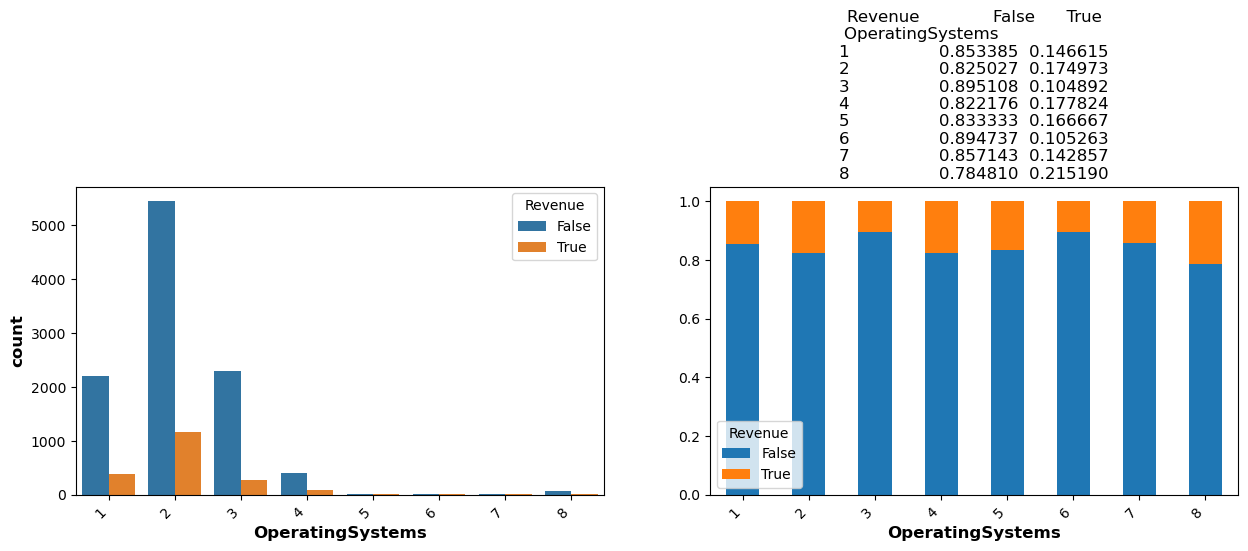

In [45]:
# Compute 'Revenue' Customers from 'OperatingSystems'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'OperatingSystems');

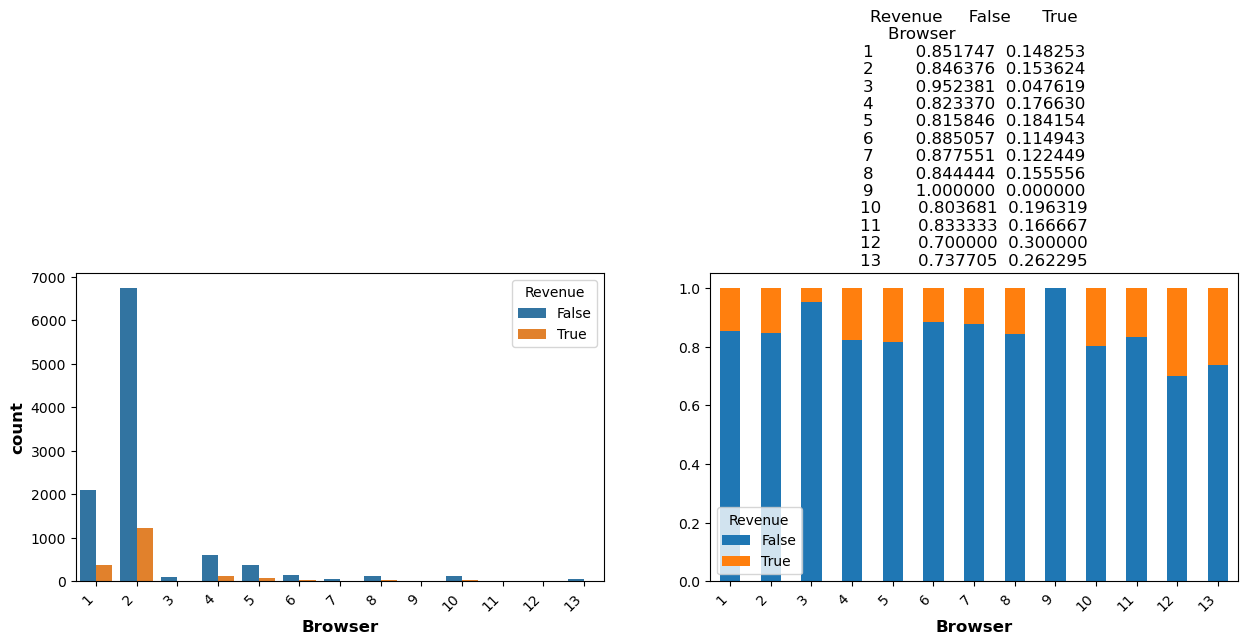

In [46]:
# Compute 'Revenue' Customers from 'Browser'

fn_BVA_categorical_plot(online_shoppers_data_df, 'Revenue', 'Browser');

### 6. Feature Realtionships (Multivariate Analysis)<a id='6'></a>

In [47]:
# Customer Profiling

online_shoppers_data_df.pivot_table('Revenue',['Weekend', 'Month'],'VisitorType',aggfunc = 'count')

VisitorType    New_Visitor  Other  Returning_Visitor
Weekend Month                                       
False   Aug             48      0                289
        Dec            264     57               1040
        Feb              1      0                155
        Jul             41      0                287
        June            24      1                216
        Mar            141      0               1285
        May            234      0               2415
        Nov            292     20               1895
        Oct             84      0                321
        Sep             86      0                266
True    Aug             24      0                 72
        Dec             71      5                290
        Feb              0      0                 28
        Jul             13      0                 91
        June             6      0                 41
        Mar             91      0                390
        May             85      0                630
        Nov            127      2                662
        Oct             40      0                104
        Sep             22      0                 74

In [48]:
# Customer Profiling

online_shoppers_data_df.pivot_table('Revenue',['Administrative', 'Informational'],'VisitorType',aggfunc = 'count')

VisitorType                   New_Visitor  Other  Returning_Visitor
Administrative Informational                                       
0              0                      462     50               4793
               1                       20      1                209
               2                       12      0                128
               3                        3      0                 50
               4                        1      1                 17
...                                   ...    ...                ...
27             12                       0      0                  0
               13                       0      0                  0
               14                       0      0                  0
               16                       0      0                  0
               24                       0      0                  0

[459 rows x 3 columns]

## 7.Feature Engineering<a id='7'></a>
Basically, all machine learning algorithms use some input data to create outputs. This input data comprise features, which are usually in the form of structured columns. Algorithms require features with some specific characteristic to work properly. Here, the need for feature engineering arises. Feature engineering efforts mainly have two goals:

Preparing the proper input dataset, compatible with the machine learning algorithm requirements.

Improving the performance of machine learning models.

The important point is that machine learning algorithms desire structured dataset because of that reason feature engineering is a key indicator for data science life cyle. Harward Business Review article stated that, "Poor data quality is enemy number one to the widespread, profitable use of machine learning. The quality demands of machine learning are steep, and bad data can rear its ugly head twice both in the historical data used to train the predictive model and in the new data used by that model to make future decisions. To ensure you have the right data for machine learning, you must have an aggressive, well-executed quality program."

Besides that, according to a survey in Forbes, data scientists spend 80% of their time on data preparation.

Some feature engineering topics can be listed as below.

- Missing Values
- Feature Generation - Binning
- Outliers
- Encoding (One-Hot Encoding, Binary Encoding, Label Encoding)
- Feature Scaling
- Feature Extraction
- Feature Interactions
- End-to-End Application

### 7.1 Handle Missing Values<a id='7.1'></a>

In [49]:
online_shoppers_data_df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

### 7.2 Feature Geneation - Binning<a id='7.2'></a>

In [50]:
# Perform binning using quartile

def bin_with_zero(df, column_name):
    """Bins a dataframe column using quartiles."""

    # Calculate quartiles, including 0
    quartiles = df[column_name].quantile([0,0.25, 0.5, 0.75, 1])
    
    # Create labels for the bins
    if column_name == 'Administrative_Duration':
        labels = ['Q1','Q2','Q3']
    elif column_name == 'Informational_Duration':
        labels = ['Q1']
    elif column_name == 'ProductRelated_Duration':
        labels = ['Q1','Q2','Q3','Q4']
    elif column_name == 'ProductRelated':
        labels = ['Q1','Q2','Q3','Q4']
    elif column_name == 'PageValues':
        labels = ['Q1']

#     # Use pd.cut to create the bins
    df[column_name+'_Bin'] = pd.cut(df[column_name], bins=quartiles, labels=labels, duplicates='drop',include_lowest=True)

    return df


In [51]:
online_shoppers_data_df = bin_with_zero(online_shoppers_data_df, 'Administrative_Duration')
online_shoppers_data_df = bin_with_zero(online_shoppers_data_df, 'Informational_Duration')
online_shoppers_data_df = bin_with_zero(online_shoppers_data_df, 'ProductRelated_Duration')
online_shoppers_data_df = bin_with_zero(online_shoppers_data_df, 'ProductRelated')
online_shoppers_data_df = bin_with_zero(online_shoppers_data_df, 'PageValues')

In [52]:
# Group Month into Quarter

qtr_dict = {'Jan':'Q1','Feb':'Q1','Mar':'Q1','Apr':'Q2','May':'Q2','June':'Q2',
            'Jul':'Q3','Aug':'Q2','Sep':'Q3','Oct':'Q4','Nov':'Q4','Dec' :'Q4'}
online_shoppers_data_df['Month_Qtr'] = online_shoppers_data_df['Month'].map(qtr_dict)
online_shoppers_data_df['Month_Qtr'] = online_shoppers_data_df['Month_Qtr'].astype('category')
online_shoppers_data_df['Month_Qtr'].value_counts()

Q4    5274
Q2    4085
Q1    2091
Q3     880
Name: Month_Qtr, dtype: int64

### 7.3 Log Transform Numeric Variables<a id='7.3'></a>

In [53]:
# Create Log column for each numerical colums

online_shoppers_data_df['Administrative_Duration_Log'] = np.log1p(online_shoppers_data_df['Administrative_Duration'])
online_shoppers_data_df['Informational_Duration_Log']  = np.log1p(online_shoppers_data_df['Informational_Duration'])
online_shoppers_data_df['ProductRelated_Log']          = np.log1p(online_shoppers_data_df['ProductRelated'])
online_shoppers_data_df['ProductRelated_Duration_Log'] = np.log1p(online_shoppers_data_df['ProductRelated_Duration'])
online_shoppers_data_df['BounceRates_Log']             = np.log1p(online_shoppers_data_df['BounceRates'])
online_shoppers_data_df['ExitRates_Log']               = np.log1p(online_shoppers_data_df['ExitRates'])
online_shoppers_data_df['PageValues_Log']              = np.log1p(online_shoppers_data_df['PageValues'])
online_shoppers_data_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,ProductRelated_Bin,PageValues_Bin,Month_Qtr,Administrative_Duration_Log,Informational_Duration_Log,ProductRelated_Log,ProductRelated_Duration_Log,BounceRates_Log,ExitRates_Log,PageValues_Log
0,0,0.000000,0,0.0,10,416.583333,0.0,0.036667,0.000000,0.0,...,Q2,Q1,Q4,0.000000,0.000000,2.397895,6.034484,0.0,0.036010,0.000000
1,0,0.000000,0,0.0,3,133.500000,0.0,0.088889,0.000000,0.0,...,Q1,Q1,Q1,0.000000,0.000000,1.386294,4.901564,0.0,0.085158,0.000000
2,5,408.408333,2,47.5,54,1547.477273,0.0,0.017333,0.000000,0.0,...,Q4,Q1,Q4,6.014713,3.881564,4.007333,7.345027,0.0,0.017185,0.000000
3,0,0.000000,0,0.0,19,686.583333,0.0,0.010526,0.000000,0.0,...,Q3,Q1,Q4,0.000000,0.000000,2.995732,6.533183,0.0,0.010471,0.000000
4,0,0.000000,0,0.0,69,2734.818254,0.0,0.004353,49.392716,0.0,...,Q4,Q1,Q2,0.000000,0.000000,4.248495,7.914186,0.0,0.004344,3.919847


### 7.4. Separate Input and Output Features<a id='7.4'></a>
Before building any machine learning model, we always separate the input variables and output variables. Input variables are those quantities whose values are changed naturally in an experiment, whereas output variable is the one whose values are dependent on the input variables. So, input variables are also known as independent variables as its values are not dependent on any other quantity, and output variable/s are also known as dependent variables as its values are dependent on other variable i.e. input variables. Like here in this data, we are trying to predict our target column 'Revenue'

By convention input variables are represented with 'X' and output variables are represented with 'y'.

In [54]:
# Function to separate input and output variables

def func_make_input_output(data,target,train_or_test):
    
    #Input variable / feature
    if train_or_test == 'train':
        x = data.drop(target, axis = 1)
        y = data[target]
        
        return x,y
    else:
        x = data
        return x

In [55]:
# Separate input and output variables

X,y = func_make_input_output(online_shoppers_data_df,'Revenue','train')

X.shape,y.shape

((12330, 30), (12330,))

### 7.5 Split the data<a id='7.5'></a>
We want to check the performance of the model that we built. For this purpose, we always split (both input and output data) the given data into training set which will be used to train the model, and test set which will be used to check how accurately the model is predicting outcomes.

For this purpose we have a class called 'train_test_split' in the 'sklearn.model_selection' module.

We split 80% of the data to the training set while 20% of the data to test set using below code.
The test_size variable is where we actually specify the proportion of the test set.

By passing our X and y variables into the train_test_split method, we are able to capture the splits in data by assigning 4 variables to the result.

In [56]:
# Function to split features into Train and Test datasets

def func_train_test_split(x_feature,y_target):
    
    from sklearn.model_selection import train_test_split
    
    X_train,X_valid,y_train,y_valid = train_test_split(x_feature,y_target,test_size=0.2,random_state=42,shuffle=True)
    
    return X_train,X_valid,y_train,y_valid

In [57]:
# Split X and y features into Train and Valid Datasets

X_train, X_valid, y_train, y_valid = func_train_test_split(X,y)
X_train.shape,y_train.shape,X_valid.shape,y_valid.shape

((9864, 30), (9864,), (2466, 30), (2466,))

In [58]:
X_train.reset_index(drop=True,inplace=True)
X_valid.reset_index(drop=True,inplace=True)

In [59]:
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,ProductRelated_Bin,PageValues_Bin,Month_Qtr,Administrative_Duration_Log,Informational_Duration_Log,ProductRelated_Log,ProductRelated_Duration_Log,BounceRates_Log,ExitRates_Log,PageValues_Log
0,1,54.5,2,132.5,14,516.500000,0.017647,0.043137,18.716417,0.0,...,Q2,Q1,Q4,4.016383,4.894101,2.708050,6.249010,0.017493,0.042233,2.981452
1,2,129.0,0,0.0,31,866.700000,0.011828,0.034101,18.111484,0.0,...,Q3,Q1,Q2,4.867534,0.000000,3.465736,6.765846,0.011759,0.033533,2.950289
2,0,0.0,0,0.0,231,11246.133790,0.001747,0.010029,0.000000,0.0,...,Q4,Q1,Q4,0.000000,0.000000,5.446737,9.327869,0.001745,0.009979,0.000000
3,0,0.0,0,0.0,8,321.000000,0.000000,0.050000,0.000000,0.2,...,Q2,Q1,Q2,0.000000,0.000000,2.197225,5.774552,0.000000,0.048790,0.000000
4,1,27.0,0,0.0,15,1486.666667,0.000000,0.013810,0.000000,0.0,...,Q2,Q1,Q2,3.332205,0.000000,2.772589,7.304964,0.000000,0.013715,0.000000


In [60]:
# Check the Distribution of the Classes in 'y_train'

y_train.value_counts(normalize=True)

False    0.843674
True     0.156326
Name: Revenue, dtype: float64

## 8. Preprocess Data<a id='8'></a>

### 8.1 Prepare List for Categorical and Numerical Datatypes<a id='8.1'></a>

In [61]:
# Create feature list by data type

def func_list_obj_types(df,col_type):
    
    # List based on shared data type
    if col_type == 'category':
        list_dtypes = [col for col in df.columns if df[col].dtype == ('category')]
    else:
        # list_dtypes = df.select_dtypes(include=['int64','float64']).columns
        list_dtypes = [col for col in df.columns if df[col].dtype in ('int64','float64')]
        
    return list_dtypes

In [62]:
# Create Feature list

X_train_cat_types = func_list_obj_types(X_train,'category')
X_train_num_types = func_list_obj_types(X_train,'num')
X_valid_cat_types = func_list_obj_types(X_valid,'category')
X_valid_num_types = func_list_obj_types(X_train,'num')

print('X_train Cat Types\n',X_train_cat_types)
print('X_train Num Types\n',X_train_num_types)

X_train Cat Types
 ['Administrative', 'Informational', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Administrative_Duration_Bin', 'Informational_Duration_Bin', 'ProductRelated_Duration_Bin', 'ProductRelated_Bin', 'PageValues_Bin', 'Month_Qtr']
X_train Num Types
 ['Administrative_Duration', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'Administrative_Duration_Log', 'Informational_Duration_Log', 'ProductRelated_Log', 'ProductRelated_Duration_Log', 'BounceRates_Log', 'ExitRates_Log', 'PageValues_Log']


In [63]:
X_train[X_train_cat_types].head()

,Administrative,Informational,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Administrative_Duration_Bin,Informational_Duration_Bin,ProductRelated_Duration_Bin,ProductRelated_Bin,PageValues_Bin,Month_Qtr
0,1,2,0.0,Dec,2,2,3,1,Returning_Visitor,False,Q2,Q1,Q2,Q2,Q1,Q4
1,2,0,0.0,May,3,2,6,1,Returning_Visitor,False,Q3,Q1,Q3,Q3,Q1,Q2
2,0,0,0.0,Nov,2,2,3,2,Returning_Visitor,True,Q1,Q1,Q4,Q4,Q1,Q4
3,0,0,0.2,May,2,2,3,4,Returning_Visitor,False,Q1,Q1,Q2,Q2,Q1,Q2
4,1,0,0.0,May,1,1,1,1,Returning_Visitor,True,Q2,Q1,Q4,Q2,Q1,Q2


### 8.2 Decide Encoding Technique for Categorical Datatypes<a id='8.2'></a>
Administrative - Frequency Encoding
<br>Informational - Frequency Encoding
<br>SpecialDay - No Encoding
<br>Month - Frequency Encoding
<br>OperatingSystems - Frequency Encoding
<br>Browser - Frequency Encoding
<br>Region - Frequency Encoding
<br>TrafficType - Frequency Encoding
<br>VisotorType - Frequency Encoding
<br>Weekendd - Binary Encoding - Frequency Encoding
<br>Administrative_Duration_Bin - Frequency Encoding
<br>Informational_Duration_Bin - Frequency Encoding
<br>ProductRelated_Duration_Bin - Frequency Encoding
<br>ProductRelated_Bin - Frequency Encoding
<br>PageValues_Bin - Frequency Encoding
<br>Month_Qtr - Frequency Encoding

### 8.3 Perform 'Frequency Encoding' for Categorical Datatypes<a id='8.3'></a> 

In [64]:
def func_frequency_encoding(df,cat_list):
    """
    Encodes a categorical variable using frequency encoding.

    """
    for col in cat_list:     
        #------------------------------------------------------------------------------------------------
        # Calculate frequency of each category
        #------------------------------------------------------------------------------------------------
        col_map = col+'_map'
        col_map = df[col].value_counts(normalize=True).to_dict()
        #------------------------------------------------------------------------------------------------
        # Replace categories with their frequencies and data type
        #------------------------------------------------------------------------------------------------
        df[col] = df[col].map(col_map)
        #------------------------------------------------------------------------------------------------
        df[col] = df[col].astype('float64')

    return df

In [65]:
X_train = func_frequency_encoding(X_train,X_train_cat_types)
X_valid = func_frequency_encoding(X_valid,X_train_cat_types)

In [66]:
X_train[X_train_cat_types].head()

,Administrative,Informational,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Administrative_Duration_Bin,Informational_Duration_Bin,ProductRelated_Duration_Bin,ProductRelated_Bin,PageValues_Bin,Month_Qtr
0,0.111111,0.059509,0.898621,0.139396,0.534063,0.646087,0.190998,0.199108,0.854826,0.766626,0.25071,1.0,0.252028,0.256488,1.0,0.425892
1,0.091545,0.785178,0.898621,0.274432,0.209043,0.646087,0.067011,0.199108,0.854826,0.766626,0.25000,1.0,0.253345,0.244424,1.0,0.332218
2,0.467153,0.785178,0.898621,0.243613,0.534063,0.646087,0.190998,0.318127,0.854826,0.233374,0.49929,1.0,0.247972,0.246148,1.0,0.425892
3,0.467153,0.785178,0.014193,0.274432,0.534063,0.646087,0.190998,0.086172,0.854826,0.766626,0.49929,1.0,0.252028,0.256488,1.0,0.332218
4,0.111111,0.785178,0.898621,0.274432,0.209246,0.199108,0.387571,0.199108,0.854826,0.233374,0.25071,1.0,0.247972,0.256488,1.0,0.332218


In [67]:
X_valid[X_train_cat_types].head()

,Administrative,Informational,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Administrative_Duration_Bin,Informational_Duration_Bin,ProductRelated_Duration_Bin,ProductRelated_Bin,PageValues_Bin,Month_Qtr
0,0.470397,0.792376,0.025547,0.266423,0.199919,0.643958,0.210462,0.059611,0.859286,0.770479,0.503650,1.0,0.263585,0.268045,1.0,0.327656
1,0.085564,0.005272,0.898216,0.142741,0.211273,0.201946,0.210462,0.314274,0.132603,0.770479,0.250203,1.0,0.236415,0.244931,1.0,0.435118
2,0.041363,0.057178,0.898216,0.038929,0.199919,0.643958,0.036902,0.022709,0.859286,0.770479,0.250203,1.0,0.258313,0.238848,1.0,0.327656
3,0.073398,0.792376,0.898216,0.266423,0.199919,0.643958,0.092863,0.314274,0.859286,0.770479,0.250203,1.0,0.236415,0.244931,1.0,0.327656
4,0.104623,0.792376,0.898216,0.241281,0.540552,0.643958,0.388078,0.059611,0.859286,0.770479,0.503650,1.0,0.258313,0.238848,1.0,0.435118


### 8.4 Perform 'Label Encoding' to 'y_train' and 'y_vlaid'<a id='8.4'></a> 

In [68]:
y_train.value_counts()

False    8322
True     1542
Name: Revenue, dtype: int64

In [69]:
y_valid.value_counts()

False    2100
True      366
Name: Revenue, dtype: int64

In [70]:
from sklearn.preprocessing import LabelEncoder

# y_train is your target variable array

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_valid = le.transform(y_valid)

In [71]:
y_train = pd.Series(y_train)
y_valid = pd.Series(y_valid)

In [72]:
y_train.value_counts()

0    8322
1    1542
dtype: int64

In [73]:
y_valid.value_counts()

0    2100
1     366
dtype: int64

### 8.5 Decide Encoding Technique for Numerical Datatypes<a id='8.5'></a>
Administrative_Duration - Drop Column
<br>Informational_Duration - Drop Column
<br>ProductRelated - Drop Column
<br>ProductRelated_Duration - Drop Column
<br>PageValues - Drop Column
<br>
<br>BounceRates - Scaling Only
<br>ExitRates - Scaling Only
<br>Administrative_Duration_Log - Scaling Only
<br>Informational_Duration_Log - Scaling Only
<br>ProductRelated_Duration_Log - Scaling Only
<br>BounceRates_Log - Scaling Only
<br>ExitRates_Log - Scaling Only
<br>PageValues_Log - Scaling Only

### 8.6 Perform 'Min Max Scaling' and Drop Columns<a id='8.6'></a> 

In [74]:
# Funtion to scale columns to prepare datasets ready for next modeling steps

def func_scale_cols(df_train,df_valid):
    
    from sklearn.preprocessing import MinMaxScaler
    #--------------------------------------------
    # Create a MinMaxScaler instance
    scaler = MinMaxScaler()
    #--------------------------------------------------------------------------------------------
    # Fit and transform the scaler on the numeric columns
    #--------------------------------------------------------------------------------------------
    df_train[['BounceRates','ExitRates','Administrative_Duration_Log','Informational_Duration_Log', \
              'ProductRelated_Duration_Log','BounceRates_Log','ExitRates_Log','PageValues_Log']] = \
        scaler.fit_transform(df_train[['BounceRates','ExitRates','Administrative_Duration_Log',
                'Informational_Duration_Log', 'ProductRelated_Duration_Log','BounceRates_Log','ExitRates_Log',\
              'PageValues_Log']])
    #--------------------------------------------------------------------------------------------
    # Transform the Valid Dataset using 'Scalar'
    #--------------------------------------------------------------------------------------------
    df_valid[['BounceRates','ExitRates','Administrative_Duration_Log','Informational_Duration_Log', \
              'ProductRelated_Duration_Log','BounceRates_Log','ExitRates_Log',\
              'PageValues_Log']] = \
        scaler.transform(df_valid[[
            'BounceRates','ExitRates','Administrative_Duration_Log','Informational_Duration_Log', \
              'ProductRelated_Duration_Log','BounceRates_Log','ExitRates_Log',\
              'PageValues_Log']])
    #--------------------------------------------------------------------------------------------
    df_train = df_train.drop(['Administrative_Duration','Informational_Duration','ProductRelated',\
                              'ProductRelated_Duration','PageValues'],axis=1)
    df_valid = df_valid.drop(['Administrative_Duration','Informational_Duration','ProductRelated',\
                              'ProductRelated_Duration','PageValues'],axis=1)
    #--------------------------------------------------------------------------------------------
    return df_train,df_valid

In [75]:
X_scaled_train,X_scaled_valid = func_scale_cols(X_train,X_valid)

In [76]:
(X_train.shape,X_scaled_train.shape,y_train.shape),(X_valid.shape,X_scaled_valid.shape,y_valid.shape)

(((9864, 30), (9864, 25), (9864,)), ((2466, 30), (2466, 25), (2466,)))

In [77]:
y_train.value_counts()

0    8322
1    1542
dtype: int64

In [78]:
y_train.dtypes

dtype('int64')

In [79]:
X_scaled_train.head()

,Administrative,Informational,BounceRates,ExitRates,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,...,ProductRelated_Bin,PageValues_Bin,Month_Qtr,Administrative_Duration_Log,Informational_Duration_Log,ProductRelated_Log,ProductRelated_Duration_Log,BounceRates_Log,ExitRates_Log,PageValues_Log
0,0.111111,0.059509,0.088235,0.215686,0.898621,0.139396,0.534063,0.646087,0.190998,0.199108,...,0.256488,1.0,0.425892,0.493932,0.62393,2.708050,0.564691,0.095947,0.231639,0.505867
1,0.091545,0.785178,0.059140,0.170507,0.898621,0.274432,0.209043,0.646087,0.067011,0.199108,...,0.244424,1.0,0.332218,0.598605,0.00000,3.465736,0.611395,0.064493,0.183921,0.500579
2,0.467153,0.785178,0.008734,0.050146,0.898621,0.243613,0.534063,0.646087,0.190998,0.318127,...,0.246148,1.0,0.425892,0.000000,0.00000,5.446737,0.842912,0.009572,0.054734,0.000000
3,0.467153,0.785178,0.000000,0.250000,0.014193,0.274432,0.534063,0.646087,0.190998,0.086172,...,0.256488,1.0,0.332218,0.000000,0.00000,2.197225,0.521817,0.000000,0.267605,0.000000
4,0.111111,0.785178,0.000000,0.069048,0.898621,0.274432,0.209246,0.199108,0.387571,0.199108,...,0.256488,1.0,0.332218,0.409792,0.00000,2.772589,0.660113,0.000000,0.075224,0.000000


In [80]:
X_scaled_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Administrative               9864 non-null   float64
 1   Informational                9864 non-null   float64
 2   BounceRates                  9864 non-null   float64
 3   ExitRates                    9864 non-null   float64
 4   SpecialDay                   9864 non-null   float64
 5   Month                        9864 non-null   float64
 6   OperatingSystems             9864 non-null   float64
 7   Browser                      9864 non-null   float64
 8   Region                       9864 non-null   float64
 9   TrafficType                  9864 non-null   float64
 10  VisitorType                  9864 non-null   float64
 11  Weekend                      9864 non-null   float64
 12  Administrative_Duration_Bin  9864 non-null   float64
 13  Informational_Dura

## 9. Build Model<a id='9'></a>

### 9.1 Import Libraries<a id='9.1'></a>

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

### 9.2 Handle the Imbalance<a id='9.2'></a>

In [121]:
# Handle imbalance using SMOTE (you can try other methods too)

# Apply SMOTE and check out the data labels: Before and Afte

print('The shape of X_scaled_train (Before SMOTE): {}'.format(X_scaled_train.shape))
print('The shape of y_train (Before SMOTE): {}'.format(y_train.shape))
print("\ny_train (Before SMOTE), counts of label '1': {}".format(sum(y_train==True)))
print("y_train (Before SMOTE), counts of label '0': {}".format(sum(y_train==False)))

The shape of X_scaled_train (Before SMOTE): (9864, 25)
The shape of y_train (Before SMOTE): (9864,)

y_train (Before SMOTE), counts of label '1': 1542
y_train (Before SMOTE), counts of label '0': 8322


In [122]:
# Apply SMOTE to the training data
sm = SMOTE(sampling_strategy='minority',random_state=0)
X_scaled_train_smote, y_train_smote = sm.fit_resample(X_scaled_train, y_train)

print('\nThe shape of X_scaled_train_smote(After SMOTE): {}'.format(X_scaled_train_smote.shape))
print('The shape of y_train_smote(After SMOTE): {}'.format(y_train_smote.shape))
print("y_train_resample(After SMOTE), counts of label '1': {}".format(sum(y_train_smote==True)))
print("y_train_resample(After SMOTE), counts of label '0': {}".format(sum(y_train_smote==False)))


The shape of X_scaled_train_smote(After SMOTE): (16644, 25)
The shape of y_train_smote(After SMOTE): (16644,)
y_train_resample(After SMOTE), counts of label '1': 8322
y_train_resample(After SMOTE), counts of label '0': 8322


### 9.3 Instantiate the Classifier and Define Parameter Grid<a id='9.3'></a>

In [170]:
# Define the SVM classifier
#-----------------------------------------------
svm_rbf = SVC()
svm_sig = SVC()
#-----------------------------------------------
# Define the parameter grid for GridSearchCV
#-----------------------------------------------
param_grid_rbf = {
    'C': [0.0001,0.001,0.01,0.5],
    'gamma': [0.0001, 0.001, 0.01, 0.5],
    'kernel': ['rbf']
}
param_grid_sig = {
    'C': [0.0001,0.01,0.1,0.5],
    'gamma': [0.001, 0.01, 0.1, 0.5],
    'kernel': ['sigmoid']
}

### 9.4 Perform GridSearchCV and Get 'Best_Estimator' and 'Best _Params'<a id='9.4'></a>

In [171]:
# Perform GridSearchCV with respective 'RBF', 'Sigmoid' and 'Poly' Kernal
#-------------------------------------------------------------------------------------------------
grid_search_rbf = GridSearchCV(svm_rbf, param_grid_rbf, cv=5, scoring='f1')
grid_search_sig = GridSearchCV(svm_sig, param_grid_sig, cv=5, scoring='f1')

In [172]:
grid_search_rbf.fit(X_scaled_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.0001, 0.001, 0.01, 0.5],
                         'gamma': [0.0001, 0.001, 0.01, 0.5],
                         'kernel': ['rbf']},
             scoring='f1')

In [178]:
import joblib

# Get the best parameters and estimator
best_estimator_rbf = grid_search_rbf.best_estimator_

# Save the model using joblib
joblib.dump(best_estimator_rbf, 'best_estimator_rbf.joblib')
# Save the model using joblib

['best_estimator_rbf.joblib']

In [179]:
grid_search_sig.fit(X_scaled_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.0001, 0.01, 0.1, 0.5],
                         'gamma': [0.001, 0.01, 0.1, 0.5],
                         'kernel': ['sigmoid']},
             scoring='f1')

In [180]:
best_estimator_sig = grid_search_sig.best_estimator_
joblib.dump(best_estimator_sig, 'best_estimator_sig.joblib')

['best_estimator_sig.joblib']

In [ ]:
# Load the model
# best_estimator_rbf = joblib.load('best_estimator_rbf.joblib')
# Load the model
# best_estimator_sig = joblib.load('best_estimator_sig.joblib')

In [195]:
best_params_rbf = grid_search_rbf.best_params_
best_params_sig = grid_search_sig.best_params_

In [181]:
#-------------------------------------------------------------------------------------------------
# Make predictions using the "best estimator" and get the probabilities for Positive Class
#-------------------------------------------------------------------------------------------------
y_train_best_pred_rbf = best_estimator_rbf.predict(X_scaled_train_smote)
y_valid_best_pred_rbf = best_estimator_rbf.predict(X_scaled_valid)
#
y_train_best_pred_sig = best_estimator_sig.predict(X_scaled_train_smote)
y_valid_best_pred_sig = best_estimator_sig.predict(X_scaled_valid)

### 9.5 Compute Model Metrices<a id='9.5'></a>

In [182]:
#-------------------------------------------------------------------------------------------------
#Compute 'Precision, Recall, F1-Score' for ''y and y_valid' Using 'best_estimator'
#-------------------------------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, f1_score, mean_squared_error, classification_report, accuracy_score, \
recall_score, log_loss, precision_score, roc_auc_score, roc_curve, precision_recall_curve, \
auc, cohen_kappa_score, balanced_accuracy_score,average_precision_score
#--------------------------------------------------------------------------------------------------
kernals=[];precision_trains=[];recall_trains=[];f1_trains=[];precision_valids=[];recall_valids=[];f1_valids=[]
#--------------------------------------------------------------------------------------------------
precision_train_rbf = precision_score(y_train_smote, y_train_best_pred_rbf)
recall_train_rbf    = recall_score(y_train_smote,    y_train_best_pred_rbf)
f1_train_rbf        = f1_score(y_train_smote,        y_train_best_pred_rbf)
#-------------------------------------------------------------------------
precision_valid_rbf = precision_score(y_valid,       y_valid_best_pred_rbf)
recall_valid_rbf    = recall_score(y_valid,          y_valid_best_pred_rbf)
f1_valid_rbf        = f1_score(y_valid,              y_valid_best_pred_rbf)
#-------------------------------------------------------------------------
kernals.append('SVM-RBF');
precision_trains.append(precision_train_rbf);recall_trains.append(recall_train_rbf);f1_trains.append(f1_train_rbf)
precision_valids.append(precision_valid_rbf);recall_valids.append(recall_valid_rbf);f1_valids.append(f1_valid_rbf)
# #---------------------------------------------------------------------------------------------------------
# #---------------------------------------------------------------------------------------------------------
precision_train_sig = precision_score(y_train_smote, y_train_best_pred_sig)
recall_train_sig    = recall_score(y_train_smote,    y_train_best_pred_sig)
f1_train_sig        = f1_score(y_train_smote,        y_train_best_pred_sig)
#-------------------------------------------------------------------------
precision_valid_sig = precision_score(y_valid,       y_valid_best_pred_sig)
recall_valid_sig    = recall_score(y_valid,          y_valid_best_pred_sig)
f1_valid_sig        = f1_score(y_valid,              y_valid_best_pred_sig)
#-------------------------------------------------------------------------
kernals.append('SVM-SIGMOID');
precision_trains.append(precision_train_sig);recall_trains.append(recall_train_sig);f1_trains.append(f1_train_sig)
precision_valids.append(precision_valid_sig);recall_valids.append(recall_valid_sig);f1_valids.append(f1_valid_sig)
#---------------------------------------------------------------------------------------------------------
#----------------------------------------------------------------------------------------------------------

In [183]:
len(kernals),len(precision_trains),len(recall_trains),len(f1_trains),len(precision_valids),len(recall_valids),len(f1_valids)

(2, 2, 2, 2, 2, 2, 2)

### 9.6 List and Visualize the Model Performance<a id='9.6'></a>

In [184]:

svm_scores   = ({
    'Kernal':kernals,
    'F1_Train':f1_trains,'Precision_Train':precision_trains,'Recall_Train':recall_trains,
    'F1_Valid':f1_valids,'Precision_Valid':precision_valids,'Recall_Valid':recall_valids
})
svm_scores_df = pd.DataFrame(svm_scores)
svm_scores_df.set_index('Kernal',drop=True,inplace=True)
svm_scores_df.head()

,F1_Train,Precision_Train,Recall_Train,F1_Valid,Precision_Valid,Recall_Valid
Kernal,,,,,,
SVM-RBF,0.862970,0.874522,0.851718,0.656587,0.542857,0.830601
SVM-SIGMOID,0.834065,0.823992,0.844388,0.580282,0.442060,0.844262


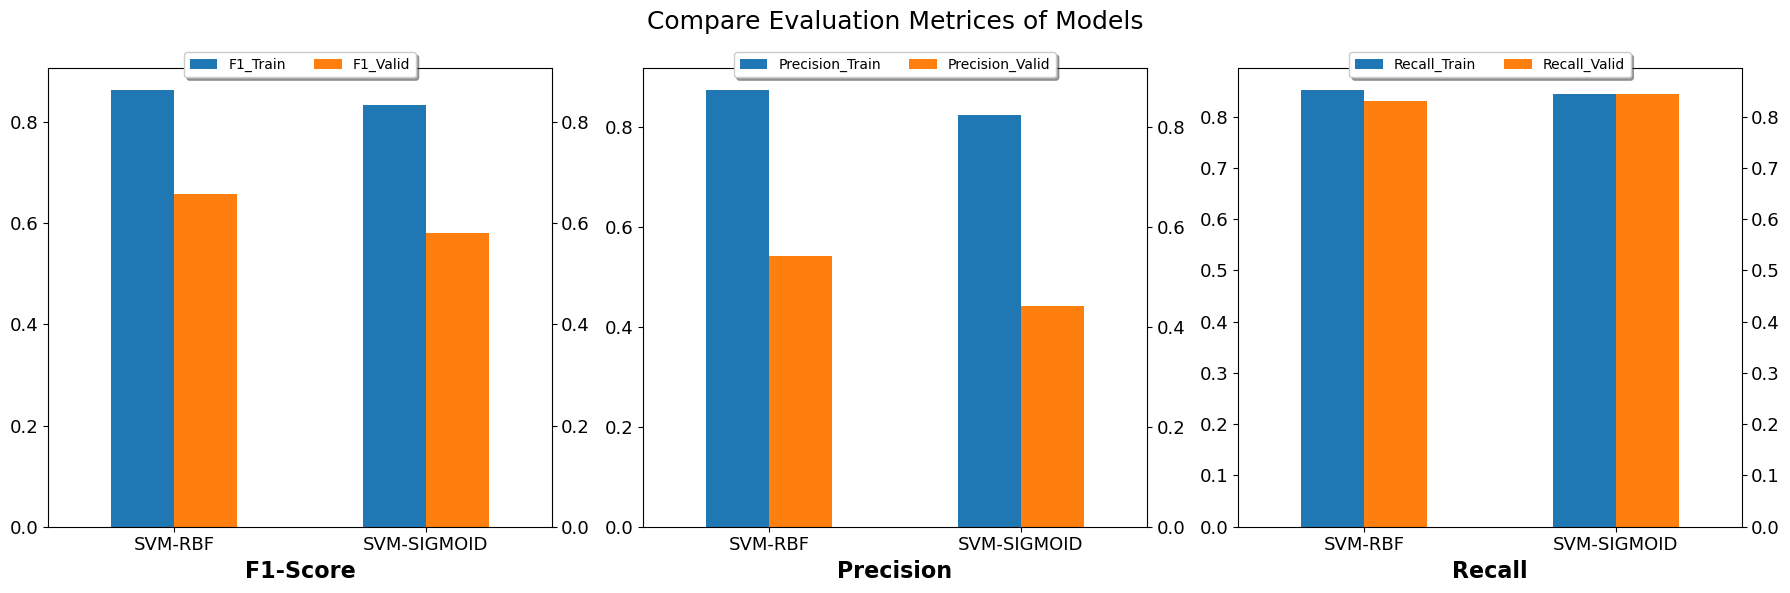

In [185]:
fig,ax = plt.subplots(figsize=(18,6), nrows=1,ncols=3)
plt.suptitle("Compare Evaluation Metrices of Models", fontsize=18)

svm_scores_df.plot(y=['F1_Train','F1_Valid'],kind='bar',ax=ax[0]);
ax[0].set_xlabel('F1-Score',fontsize=16,weight='bold')
ax[0].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

svm_scores_df.plot(y=['Precision_Train','Precision_Valid'],kind='bar',ax=ax[1]);
ax[1].set_xlabel('Precision',fontsize=16,weight='bold')
ax[1].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

svm_scores_df.plot(y=['Recall_Train','Recall_Valid'],kind='bar',ax=ax[2]);
ax[2].set_xlabel('Recall',fontsize=16,weight='bold')
ax[2].tick_params(labelbottom=True, labelright=True,bottom=True,right=True,labelrotation=0,labelsize=13)
ax[2].legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),ncols=4,fancybox=True, shadow=True)

plt.tight_layout()
plt.show()